#Predicting Histone Modifications from DNA Sequence Using Deep Learning
Akshaj Chandwani,
Devanshu Khadka,
Sameeksha Kini,
Jenitha Patel,

Machine Learning 2 Final Project

In [ ]:

# 1. Problem Statement
# Project: Multi-label Histone Modification Prediction
# Dataset: InstaDeepAI Nucleotide Transformer downstream tasks
# Task: Predict 10 binary histone modification labels per DNA sequence
# Models: CNN, CNN+BiLSTM, Transformer Encoder, Supervised CNN-VAE


!pip install -q datasets transformers evaluate torchmetrics scikit-learn seaborn

import os
import random
import math
import time
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    hamming_loss,
    accuracy_score,
    classification_report
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 72.2 MB/s eta 0:00:00
PyTorch version: 2.10.0+cu128
CUDA available: True
Using device: cuda
GPU: NVIDIA A100-SXM4-80GB


In [ ]:

# Global configuration


SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# Histone labels / HuggingFace config names
HISTONE_TASKS = [
    "H3",
    "H4",
    "H3K4me1",
    "H3K4me2",
    "H3K4me3",
    "H3K9ac",
    "H3K14ac",
    "H3K36me3",
    "H3K79me3",
    "H4ac"
]

NUM_LABELS = len(HISTONE_TASKS)

# Modular switches
RUN_CNN = True
RUN_CNN_BILSTM = True
RUN_TRANSFORMER = True
RUN_VAE = True

# Full dataset mode
USE_FULL_DATASET = True

# Optional safety limit.
# Keep these as None for full dataset.
MAX_TRAIN_SAMPLES = None
MAX_VAL_SAMPLES = None
MAX_TEST_SAMPLES = None

# Training parameters
BATCH_SIZE = 128
EPOCHS_CNN = 20
EPOCHS_BILSTM = 20
EPOCHS_TRANSFORMER = 20
EPOCHS_VAE = 20

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 3

# Sequence handling
# The benchmark sequences are usually manageable, but Transformer is O(L^2).
# 512 is a safe max length for Colab T4.
MAX_LEN_CAP = 512

print("Number of labels:", NUM_LABELS)
print("Histone tasks:", HISTONE_TASKS)

Number of labels: 10
Histone tasks: ['H3', 'H4', 'H3K4me1', 'H3K4me2', 'H3K4me3', 'H3K9ac', 'H3K14ac', 'H3K36me3', 'H3K79me3', 'H4ac']


In [ ]:

# 1. Problem Statement


problem_statement = """
This project predicts multiple histone modification labels from DNA sequences.
The original HuggingFace benchmark provides separate binary classification tasks
for each histone mark. I combine the ten binary tasks into one multi-label
classification problem, where each DNA sequence receives a length-10 binary
label vector.

The model predicts the following histone marks:
H3, H4, H3K4me1, H3K4me2, H3K4me3, H3K9ac, H3K14ac,
H3K36me3, H3K79me3, and H4ac.

Because each sequence can have more than one positive histone label at the same
time, this is a multi-label classification task rather than a multi-class task.
The models use sigmoid outputs and binary cross-entropy loss.
"""

print(problem_statement)


This project predicts multiple histone modification labels from DNA sequences.
The original HuggingFace benchmark provides separate binary classification tasks
for each histone mark. I combine the ten binary tasks into one multi-label
classification problem, where each DNA sequence receives a length-10 binary
label vector.

The model predicts the following histone marks:
H3, H4, H3K4me1, H3K4me2, H3K4me3, H3K9ac, H3K14ac,
H3K36me3, H3K79me3, and H4ac.

Because each sequence can have more than one positive histone label at the same
time, this is a multi-label classification task rather than a multi-class task.
The models use sigmoid outputs and binary cross-entropy loss.



In [ ]:

# 2. Assumptions / Hypotheses about Data and Model


assumptions = """
Assumptions and hypotheses:

1. DNA sequence patterns contain useful signals for predicting histone marks.
2. Each histone modification can be modeled as a separate binary output.
3. The ten labels are not mutually exclusive, so sigmoid activation is more
   appropriate than softmax.
4. CNN models may detect local nucleotide motifs.
5. CNN + BiLSTM models may capture both local motifs and sequence order.
6. Transformer models may capture longer-range relationships in the sequence.
7. A supervised VAE may learn a compressed latent representation that helps
   preserve sequence structure while also predicting histone labels.
8. Macro AUROC is the primary selection metric because accuracy can be misleading
   when labels are imbalanced.
"""

print(assumptions)


Assumptions and hypotheses:

1. DNA sequence patterns contain useful signals for predicting histone marks.
2. Each histone modification can be modeled as a separate binary output.
3. The ten labels are not mutually exclusive, so sigmoid activation is more
   appropriate than softmax.
4. CNN models may detect local nucleotide motifs.
5. CNN + BiLSTM models may capture both local motifs and sequence order.
6. Transformer models may capture longer-range relationships in the sequence.
7. A supervised VAE may learn a compressed latent representation that helps
   preserve sequence structure while also predicting histone labels.
8. Macro AUROC is the primary selection metric because accuracy can be misleading
   when labels are imbalanced.



In [ ]:

# 3. Exploratory Data Analysis
# Correctly load default dataset and inspect task structure


from datasets import load_dataset, get_dataset_config_names
import pandas as pd
import numpy as np

DATASET_NAME = "InstaDeepAI/nucleotide_transformer_downstream_tasks"

EXPECTED_HISTONE_TASKS = [
    "H3",
    "H4",
    "H3K4me1",
    "H3K4me2",
    "H3K4me3",
    "H3K9ac",
    "H3K14ac",
    "H3K36me3",
    "H3K79me3",
    "H4ac"
]

configs = get_dataset_config_names(DATASET_NAME)
print("Available configurations:", configs)

ds = load_dataset(DATASET_NAME, "default")
print(ds)

for split in ds.keys():
    print(f"\n===== {split.upper()} =====")
    print("Columns:", ds[split].column_names)
    print("Rows:", len(ds[split]))
    print("First example:")
    print(ds[split][0])

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Available configurations: ['default']


Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

...

splice_sites_all/test.parquet:   0%|          | 0.00/594k [00:00<?, ?B/s]

splice_sites_donors/test.parquet:   0%|          | 0.00/655k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/461850 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/48797 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sequence', 'name', 'label', 'task'],
        num_rows: 461850
    })
    test: Dataset({
        features: ['sequence', 'name', 'label', 'task'],
        num_rows: 48797
    })
})

===== TRAIN =====
Columns: ['sequence', 'name', 'label', 'task']
Rows: 461850
First example:
{'sequence': 'TCACTTCGATTATTGAGGCAGTCTTCATTAAAGTTTATTACAATGGATATGGTATCACCAGTCTTGAACCTACAATCATCTATTTTAGGTGAGCTCGTAGGCATTATTGGAAAAGTGTTCTTTCTCTTAATAGAAGAGATTAAATACCCGATAATCACACCCAAAATTATTGTGGATGCCCAGATATCTTCTTGGTCATTGTTTTTTTTCGCTTCAATCTGTAATCTCTCTGCAAAATTTCGGGAGCCAATAGTGACAACATCGTCAATAATAAGTTTGATGGAATCGGAAAAAGATCTTAAAAATGTAAATGAGTATTTCCAAATAATGGCCAAAATGCTCTTTATATTGGAAAATAAAATAGTTGTTTCGCTCTTCGTAGTATTTAACATTTCCGTTCTTATCATTGTAAAGTCTGAGCCATATTCATATGGAAAAGTGCTTTTTAAACCTAGTTCCTCCATATTTTAGTTTTTTATCGATATTGGAAAAAAAAGAGC', 'name': 'YBR063C_YBR063C_367930|0', 'label': 0, 'task': 'H3'}

===== TEST =====
Columns: ['sequence', 'name', 'label', 'task']
Rows: 48797
First example:


In [ ]:

# Diagnose column names and task values


for split in ds.keys():
    df_preview = ds[split].to_pandas()
    print(f"\n===== {split.upper()} =====")
    print("Columns:", df_preview.columns.tolist())

    if "task" in df_preview.columns:
        print("\nUnique task values:")
        print(sorted(df_preview["task"].astype(str).unique().tolist()))

        print("\nTask counts:")
        display(df_preview["task"].value_counts().head(30))

    elif "task_name" in df_preview.columns:
        print("\nUnique task_name values:")
        print(sorted(df_preview["task_name"].astype(str).unique().tolist()))

    else:
        print("No obvious task column found.")

    break


===== TRAIN =====
Columns: ['sequence', 'name', 'label', 'task']

Unique task values:
['H3', 'H3K14ac', 'H3K36me3', 'H3K4me1', 'H3K4me2', 'H3K4me3', 'H3K79me3', 'H3K9ac', 'H4', 'H4ac', 'enhancers', 'enhancers_types', 'promoter_all', 'promoter_no_tata', 'promoter_tata', 'splice_sites_acceptors', 'splice_sites_all', 'splice_sites_donors']

Task counts:


,count
task,
promoter_all,53276
promoter_no_tata,47767
H3K4me3,33119
H3K36me3,31392
H4ac,30685
H3K14ac,29743
H3K4me1,28509
H3K4me2,27614
splice_sites_all,27000


In [ ]:

# Build masked multi-label dataset
# This keeps ALL available sequences, even if not every sequence
# has all 10 histone labels.


EXPECTED_HISTONE_TASKS = [
    "H3",
    "H4",
    "H3K4me1",
    "H3K4me2",
    "H3K4me3",
    "H3K9ac",
    "H3K14ac",
    "H3K36me3",
    "H3K79me3",
    "H4ac"
]

def find_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def build_masked_multilabel_split(hf_split, split_name):
    df = hf_split.to_pandas()

    seq_col = find_column(df, ["sequence", "seq", "dna_sequence", "text"])
    label_col = find_column(df, ["label", "labels", "target", "y"])
    task_col = find_column(df, ["task", "task_name", "label_name", "histone", "mark"])

    print(f"\nBuilding masked split: {split_name}")
    print("Columns:", df.columns.tolist())
    print("Sequence column:", seq_col)
    print("Label column:", label_col)
    print("Task column:", task_col)

    if seq_col is None or label_col is None or task_col is None:
        raise ValueError("Could not find sequence, label, and task columns.")

    df[task_col] = df[task_col].astype(str)

    histone_df = df[df[task_col].isin(EXPECTED_HISTONE_TASKS)].copy()
    histone_df[label_col] = histone_df[label_col].astype(float)

    # Pivot labels wide
    wide = histone_df.pivot_table(
        index=seq_col,
        columns=task_col,
        values=label_col,
        aggfunc="first"
    ).reset_index()

    wide = wide.rename(columns={seq_col: "sequence"})

    # Add missing histone columns if needed
    for task in EXPECTED_HISTONE_TASKS:
        if task not in wide.columns:
            wide[task] = np.nan

    # Create mask columns: 1 if label exists, 0 if missing
    for task in EXPECTED_HISTONE_TASKS:
        wide[f"{task}_mask"] = wide[task].notna().astype(float)

    # Fill missing labels with 0, but mask prevents them from affecting loss
    for task in EXPECTED_HISTONE_TASKS:
        wide[task] = wide[task].fillna(0).astype(float)

    wide["labels"] = wide[EXPECTED_HISTONE_TASKS].values.tolist()
    wide["label_mask"] = wide[[f"{t}_mask" for t in EXPECTED_HISTONE_TASKS]].values.tolist()

    print("Final shape:", wide.shape)
    print("Average labels available per sequence:", wide[[f"{t}_mask" for t in EXPECTED_HISTONE_TASKS]].sum(axis=1).mean())

    return wide

multi_splits = {}

for split in ds.keys():
    multi_splits[split] = build_masked_multilabel_split(ds[split], split)
    display(multi_splits[split].head())


Building masked split: train
Columns: ['sequence', 'name', 'label', 'task']
Sequence column: sequence
Label column: label
Task column: task
Final shape: (41274, 23)
Average labels available per sequence: 6.266075495469303


task,sequence,H3,H3K14ac,H3K36me3,H3K4me1,H3K4me2,H3K4me3,H3K79me3,H3K9ac,H4,...,H3K4me1_mask,H3K4me2_mask,H3K4me3_mask,H3K9ac_mask,H3K14ac_mask,H3K36me3_mask,H3K79me3_mask,H4ac_mask,labels,label_mask
0,AAAAAAAAAAAAAAAAAAAACAAGAGCCAGCAAACTGACATTAACA...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,"[0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
1,AAAAAAAAAAAAACATATATTTTGCTATGAATTATAATAAGTAAAT...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, ..."
2,AAAAAAAAAAAAATAAAGTTAGGACTAGCGATTGTCGTAGACGCAC...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,"[0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, ..."
3,AAAAAAAAAAAAATCAACAAAAATTCCAACTTTTCAATGATGAATG...,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,"[0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, ...","[0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, ..."
4,AAAAAAAAAAACATAAGGAAATTTTAATTAAATAGTCTATCTACAC...,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,"[1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, ...","[1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."



Building masked split: test
Columns: ['sequence', 'name', 'label', 'task']
Sequence column: sequence
Label column: label
Task column: task
Final shape: (21189, 23)
Average labels available per sequence: 1.3564113455094624


task,sequence,H3,H3K14ac,H3K36me3,H3K4me1,H3K4me2,H3K4me3,H3K79me3,H3K9ac,H4,...,H3K4me1_mask,H3K4me2_mask,H3K4me3_mask,H3K9ac_mask,H3K14ac_mask,H3K36me3_mask,H3K79me3_mask,H4ac_mask,labels,label_mask
0,AAAAAAAAAAAAATAAAGTTAGGACTAGCGATTGTCGTAGACGCAC...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,AAAAAAAAAAAGATCAAAACCAAACTTCGTATTCGAGCCTAAAAAA...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ..."
2,AAAAAAAAAAGAAAAAGATAATATAATATAATACCTTTATATATGT...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ..."
3,AAAAAAAAAAGGGAACCTCTGGTTACGATGATATACCTGCGTGAAA...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,AAAAAAAAAATAATAATGCAAAATGTATAAATGTATAAGAGTCTTT...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [ ]:

# Create Train / Validation / Test Splits


available = set(multi_splits.keys())
print("Available splits:", available)

if "train" not in available:
    raise ValueError("No train split found.")

if "validation" in available:
    train_df = multi_splits["train"].copy()
    val_df = multi_splits["validation"].copy()
elif "val" in available:
    train_df = multi_splits["train"].copy()
    val_df = multi_splits["val"].copy()
else:
    print("No validation split found. Creating 80/20 validation split from train.")
    full_train = multi_splits["train"].sample(frac=1, random_state=SEED).reset_index(drop=True)
    val_size = int(0.2 * len(full_train))
    val_df = full_train.iloc[:val_size].reset_index(drop=True)
    train_df = full_train.iloc[val_size:].reset_index(drop=True)

if "test" in available:
    test_df = multi_splits["test"].copy()
else:
    print("No test split found. Creating test split from validation.")
    full_val = val_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    test_size = int(0.5 * len(full_val))
    test_df = full_val.iloc[:test_size].reset_index(drop=True)
    val_df = full_val.iloc[test_size:].reset_index(drop=True)

HISTONE_TASKS = EXPECTED_HISTONE_TASKS
NUM_LABELS = len(HISTONE_TASKS)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())

Available splits: {'test', 'train'}
No validation split found. Creating 80/20 validation split from train.
Train shape: (33020, 23)
Validation shape: (8254, 23)
Test shape: (21189, 23)


task,sequence,H3,H3K14ac,H3K36me3,H3K4me1,H3K4me2,H3K4me3,H3K79me3,H3K9ac,H4,...,H3K4me1_mask,H3K4me2_mask,H3K4me3_mask,H3K9ac_mask,H3K14ac_mask,H3K36me3_mask,H3K79me3_mask,H4ac_mask,labels,label_mask
0,TGTAATTTCAATGTCCTTACAAGGTGACAAGCGTTTAATATGGACA...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, ..."
1,GGAAAAAAAAGAAAGAAAATTGCGTATAGCGGGAACGGGAGAATAC...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, ..."
2,AATATAAACATATAAAACGGAATGAGGAATAATCGTAATATTAGTA...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...","[1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, ..."
3,ATAATTCAAGTTTTATCATTATATCATTTTTAAATATTTGATTATC...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, ...","[1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, ..."
4,GCATCGAAGATGTAACAGATTTATTTGCCGATTTACAGTCAGGTGA...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, ..."


Positive label rates:


,0
task,
H3,0.167565
H4,0.142035
H3K4me1,0.375954
H3K4me2,0.394155
H3K4me3,0.427498
H3K9ac,0.335342
H3K14ac,0.409328
H3K36me3,0.409419
H3K79me3,0.333374



Label correlation:


task,H3,H4,H3K4me1,H3K4me2,H3K4me3,H3K9ac,H3K14ac,H3K36me3,H3K79me3,H4ac
task,,,,,,,,,,
H3,1.000000,0.109435,-0.042883,0.156833,0.173358,0.187137,0.193141,-0.157370,-0.055310,0.257107
H4,0.109435,1.000000,0.123723,0.032562,-0.048745,-0.067211,-0.116049,0.128585,0.163136,-0.066707
H3K4me1,-0.042883,0.123723,1.000000,0.084568,-0.300789,-0.175601,-0.344135,0.304590,0.158028,-0.224932
H3K4me2,0.156833,0.032562,0.084568,1.000000,0.382844,0.189491,0.262864,-0.072290,-0.018781,0.342196
H3K4me3,0.173358,-0.048745,-0.300789,0.382844,1.000000,0.349099,0.562717,-0.254756,-0.043749,0.533402
H3K9ac,0.187137,-0.067211,-0.175601,0.189491,0.349099,1.000000,0.471151,-0.221966,-0.193013,0.494350
H3K14ac,0.193141,-0.116049,-0.344135,0.262864,0.562717,0.471151,1.000000,-0.383990,-0.180019,0.604758
H3K36me3,-0.157370,0.128585,0.304590,-0.072290,-0.254756,-0.221966,-0.383990,1.000000,0.416642,-0.339390
H3K79me3,-0.055310,0.163136,0.158028,-0.018781,-0.043749,-0.193013,-0.180019,0.416642,1.000000,-0.156839



Are labels identical to first label?
{'H4': False, 'H3K4me1': False, 'H3K4me2': False, 'H3K4me3': False, 'H3K9ac': False, 'H3K14ac': False, 'H3K36me3': False, 'H3K79me3': False, 'H4ac': False}


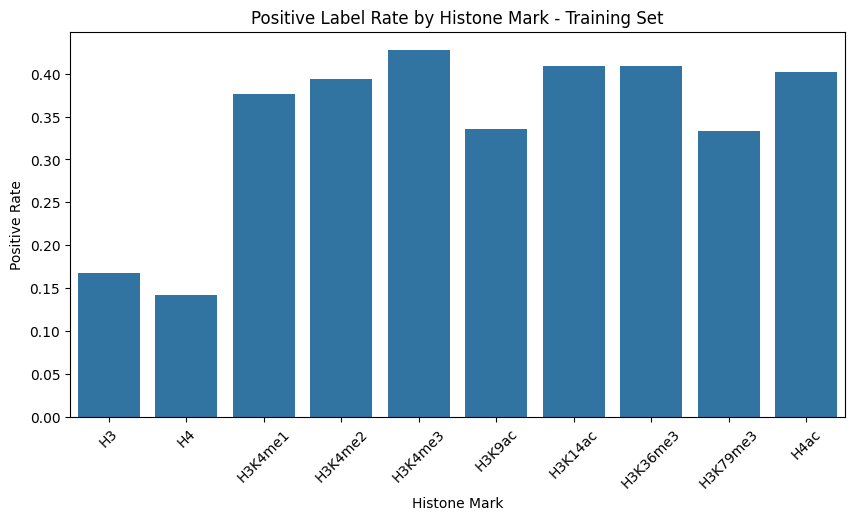

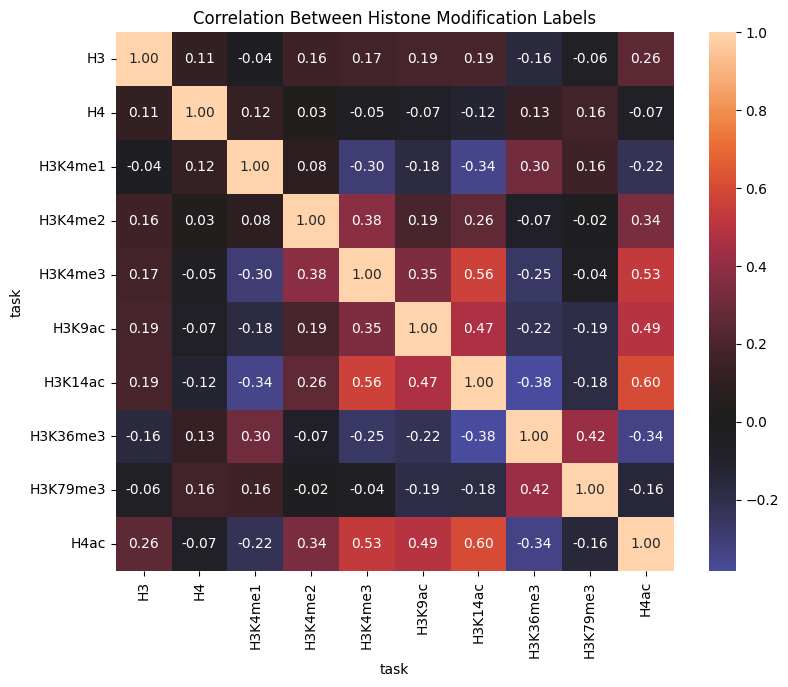

In [ ]:

# Critical sanity checks
# Labels should NOT all be identical.


label_rates = train_df[HISTONE_TASKS].mean()
label_corr = train_df[HISTONE_TASKS].corr()

print("Positive label rates:")
display(label_rates)

print("\nLabel correlation:")
display(label_corr)

# Check whether all label columns are exactly identical
identical_to_first = {}
first_label = HISTONE_TASKS[0]

for label in HISTONE_TASKS[1:]:
    identical_to_first[label] = train_df[first_label].equals(train_df[label])

print("\nAre labels identical to first label?")
print(identical_to_first)

if all(identical_to_first.values()):
    raise ValueError(
        "All histone labels are identical. The multi-label dataset is still wrong. "
        "Do not train models yet."
    )

plt.figure(figsize=(10, 5))
sns.barplot(x=label_rates.index, y=label_rates.values)
plt.title("Positive Label Rate by Histone Mark - Training Set")
plt.xlabel("Histone Mark")
plt.ylabel("Positive Rate")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(label_corr, annot=True, center=0, fmt=".2f")
plt.title("Correlation Between Histone Modification Labels")
plt.show()

Train sequence length summary:


,seq_len
count,33020.000000
mean,499.986342
std,1.583506
min,290.000000
25%,500.000000
50%,500.000000
75%,500.000000
max,500.000000


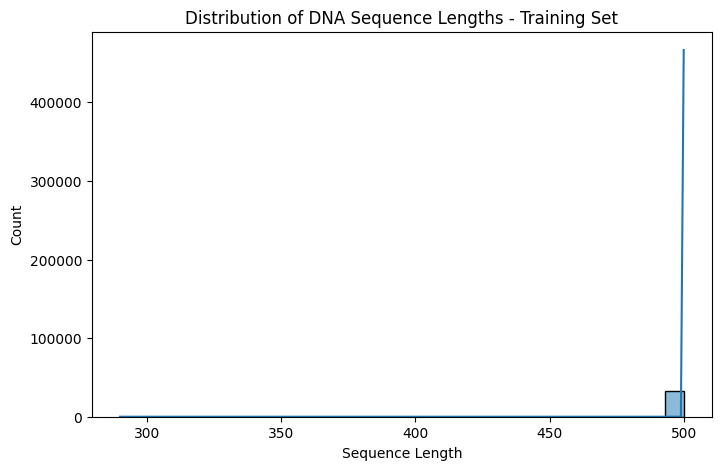

Maximum sequence length in train: 500
Using MAX_LEN: 500


In [ ]:

# 3. Exploratory Data Analysis
# Sequence length distribution


for df in [train_df, val_df, test_df]:
    df["seq_len"] = df["sequence"].apply(len)

print("Train sequence length summary:")
display(train_df["seq_len"].describe())

plt.figure(figsize=(8, 5))
sns.histplot(train_df["seq_len"], bins=30, kde=True)
plt.title("Distribution of DNA Sequence Lengths - Training Set")
plt.xlabel("Sequence Length")
plt.ylabel("Count")
plt.show()

MAX_LEN = min(int(train_df["seq_len"].max()), MAX_LEN_CAP)
print("Maximum sequence length in train:", train_df["seq_len"].max())
print("Using MAX_LEN:", MAX_LEN)

,positive_count,positive_rate
task,,
H3K4me3,14116.0,0.427498
H3K36me3,13519.0,0.409419
H3K14ac,13516.0,0.409328
H4ac,13264.0,0.401696
H3K4me2,13015.0,0.394155
H3K4me1,12414.0,0.375954
H3K9ac,11073.0,0.335342
H3K79me3,11008.0,0.333374
H3,5533.0,0.167565


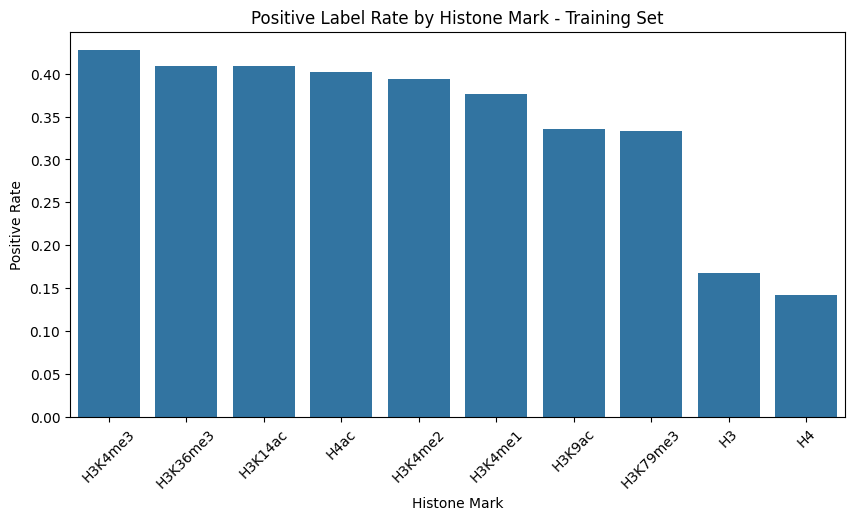

In [ ]:

# Label balance visualization


label_counts = train_df[HISTONE_TASKS].sum().sort_values(ascending=False)
label_rates = train_df[HISTONE_TASKS].mean().sort_values(ascending=False)

label_summary = pd.DataFrame({
    "positive_count": label_counts,
    "positive_rate": label_rates
})

display(label_summary)

plt.figure(figsize=(10, 5))
sns.barplot(x=label_summary.index, y=label_summary["positive_rate"])
plt.title("Positive Label Rate by Histone Mark - Training Set")
plt.xlabel("Histone Mark")
plt.ylabel("Positive Rate")
plt.xticks(rotation=45)
plt.show()

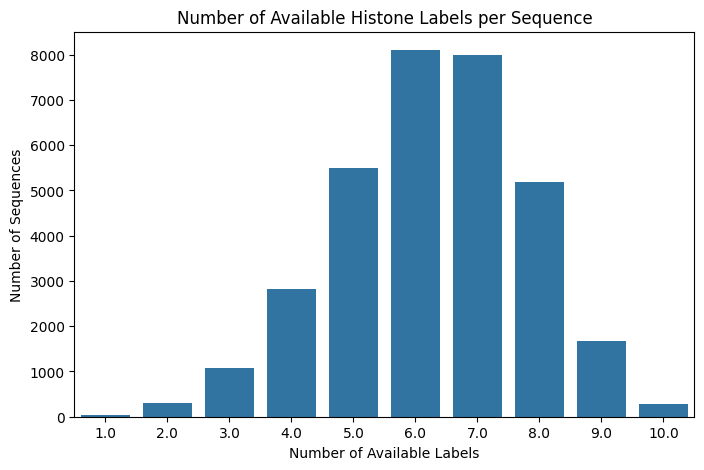

Average available labels per sequence: 6.264142943670502


,num_available_labels
count,33020.000000
mean,6.264143
std,1.545460
min,1.000000
25%,5.000000
50%,6.000000
75%,7.000000
max,10.000000


In [ ]:

# EDA: How many labels are available per sequence?

mask_cols = [f"{t}_mask" for t in HISTONE_TASKS]

train_df["num_available_labels"] = train_df[mask_cols].sum(axis=1)

plt.figure(figsize=(8, 5))
sns.countplot(x=train_df["num_available_labels"])
plt.title("Number of Available Histone Labels per Sequence")
plt.xlabel("Number of Available Labels")
plt.ylabel("Number of Sequences")
plt.show()

print("Average available labels per sequence:", train_df["num_available_labels"].mean())
display(train_df["num_available_labels"].describe())

,label,available_count,positive_count,positive_rate_observed_only
3,H3K4me2,21992,13015,0.591806
6,H3K14ac,23762,13516,0.568807
5,H3K9ac,20012,11073,0.553318
2,H3K4me1,22823,12414,0.543925
9,H4ac,24512,13264,0.541123
7,H3K36me3,25110,13519,0.538391
4,H3K4me3,26478,14116,0.533122
8,H3K79me3,20766,11008,0.530097
0,H3,10810,5533,0.511841
1,H4,10577,4690,0.443415


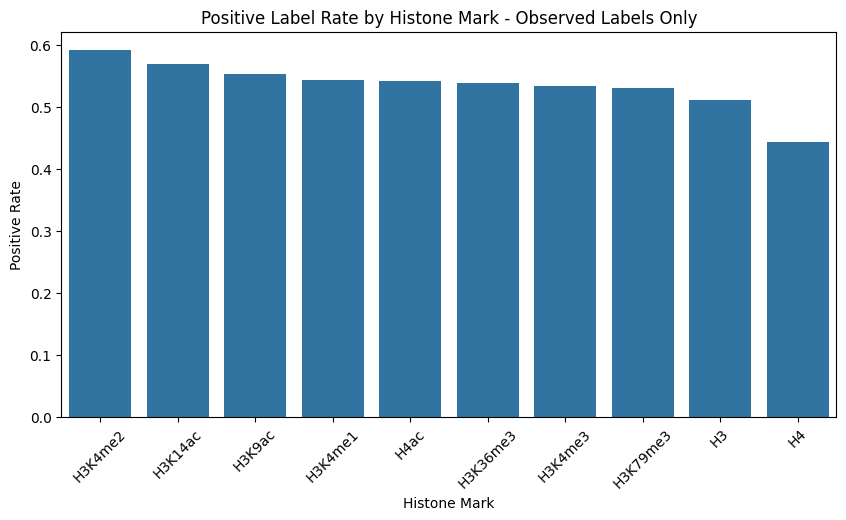

In [ ]:

# EDA: Positive label rate using only observed labels
# Missing labels are excluded using the mask.


observed_label_summary = []

for task in HISTONE_TASKS:
    mask_col = f"{task}_mask"

    available_n = train_df[mask_col].sum()
    positive_n = train_df.loc[train_df[mask_col] == 1, task].sum()

    positive_rate = positive_n / available_n if available_n > 0 else np.nan

    observed_label_summary.append({
        "label": task,
        "available_count": int(available_n),
        "positive_count": int(positive_n),
        "positive_rate_observed_only": positive_rate
    })

observed_label_summary = pd.DataFrame(observed_label_summary)
observed_label_summary = observed_label_summary.sort_values(
    by="positive_rate_observed_only",
    ascending=False
)

display(observed_label_summary)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=observed_label_summary,
    x="label",
    y="positive_rate_observed_only"
)
plt.title("Positive Label Rate by Histone Mark - Observed Labels Only")
plt.xlabel("Histone Mark")
plt.ylabel("Positive Rate")
plt.xticks(rotation=45)
plt.show()

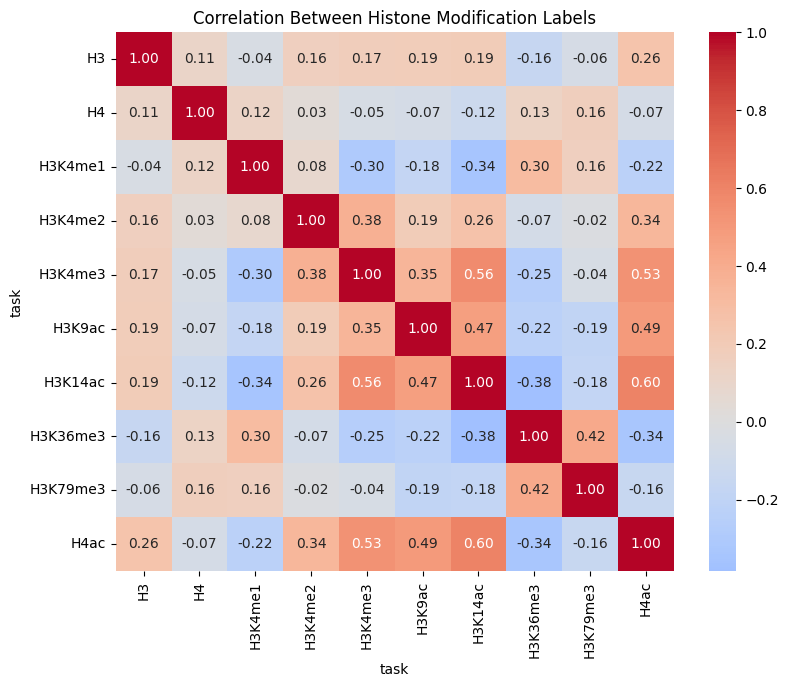

In [ ]:

# Label correlation heatmap


corr = train_df[HISTONE_TASKS].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Between Histone Modification Labels")
plt.show()

In [ ]:

# 4. Feature Engineering & Data Transformations
# DNA sequence tokenization


# Vocabulary:
# 0 = PAD
# 1 = A
# 2 = C
# 3 = G
# 4 = T
# 5 = N / unknown

VOCAB = {
    "A": 1,
    "C": 2,
    "G": 3,
    "T": 4,
    "N": 5
}

PAD_IDX = 0
VOCAB_SIZE = 6

def encode_sequence(seq, max_len=MAX_LEN):
    seq = seq.upper()
    ids = [VOCAB.get(ch, 5) for ch in seq[:max_len]]

    if len(ids) < max_len:
        ids += [PAD_IDX] * (max_len - len(ids))

    return np.array(ids, dtype=np.int64)

class HistoneDataset(Dataset):
    def __init__(self, dataframe, max_len=MAX_LEN):
        self.df = dataframe.reset_index(drop=True)
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        seq = self.df.loc[idx, "sequence"]
        labels = self.df.loc[idx, HISTONE_TASKS].values.astype(np.float32)

        input_ids = encode_sequence(seq, self.max_len)
        attention_mask = (input_ids != PAD_IDX).astype(np.float32)

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.float32)
        }

train_dataset = HistoneDataset(train_df, MAX_LEN)
val_dataset = HistoneDataset(val_df, MAX_LEN)
test_dataset = HistoneDataset(test_df, MAX_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

batch = next(iter(train_loader))
print("input_ids shape:", batch["input_ids"].shape)
print("attention_mask shape:", batch["attention_mask"].shape)
print("labels shape:", batch["labels"].shape)
print("First encoded sequence:", batch["input_ids"][0][:20])
print("First label vector:", batch["labels"][0])

input_ids shape: torch.Size([128, 500])
attention_mask shape: torch.Size([128, 500])
labels shape: torch.Size([128, 10])
First encoded sequence: tensor([2, 4, 1, 3, 4, 3, 4, 3, 1, 1, 2, 4, 2, 1, 2, 4, 2, 1, 2, 4])
First label vector: tensor([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])


In [ ]:

# Compute positive class weights for BCEWithLogitsLoss
# This helps with imbalanced labels.


label_matrix = train_df[HISTONE_TASKS].values.astype(np.float32)

positive_counts = label_matrix.sum(axis=0)
negative_counts = label_matrix.shape[0] - positive_counts

pos_weight = negative_counts / np.maximum(positive_counts, 1)
pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(DEVICE)

pos_weight_df = pd.DataFrame({
    "label": HISTONE_TASKS,
    "positive_count": positive_counts,
    "negative_count": negative_counts,
    "pos_weight": pos_weight.detach().cpu().numpy()
})

display(pos_weight_df)

criterion_bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

,label,positive_count,negative_count,pos_weight
0,H3,5533.0,27487.0,4.967829
1,H4,4690.0,28330.0,6.040512
2,H3K4me1,12414.0,20606.0,1.659900
3,H3K4me2,13015.0,20005.0,1.537073
4,H3K4me3,14116.0,18904.0,1.339190
5,H3K9ac,11073.0,21947.0,1.982028
6,H3K14ac,13516.0,19504.0,1.443030
7,H3K36me3,13519.0,19501.0,1.442488
8,H3K79me3,11008.0,22012.0,1.999637
9,H4ac,13264.0,19756.0,1.489445


In [ ]:

# Evaluation metrics
# Primary metric: Macro AUROC
# Secondary metrics: Micro AUROC, Macro F1, Hamming Loss,
# Per-label accuracy, Exact-match accuracy, AUPRC


def sigmoid_np(x):
    return 1 / (1 + np.exp(-x))

def compute_metrics(y_true, logits, threshold=0.5):
    """
    y_true: numpy array shape [n_samples, num_labels]
    logits: numpy array shape [n_samples, num_labels]
    """
    probs = sigmoid_np(logits)
    y_pred = (probs >= threshold).astype(int)

    metrics = {}

    # AUROC can fail if a label has only one class in a split.
    per_label_auroc = []
    per_label_auprc = []

    for j in range(y_true.shape[1]):
        if len(np.unique(y_true[:, j])) > 1:
            per_label_auroc.append(roc_auc_score(y_true[:, j], probs[:, j]))
            per_label_auprc.append(average_precision_score(y_true[:, j], probs[:, j]))
        else:
            per_label_auroc.append(np.nan)
            per_label_auprc.append(np.nan)

    metrics["macro_auroc"] = np.nanmean(per_label_auroc)
    metrics["macro_auprc"] = np.nanmean(per_label_auprc)

    try:
        metrics["micro_auroc"] = roc_auc_score(y_true.ravel(), probs.ravel())
    except:
        metrics["micro_auroc"] = np.nan

    metrics["macro_f1"] = f1_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["micro_f1"] = f1_score(y_true, y_pred, average="micro", zero_division=0)

    metrics["hamming_loss"] = hamming_loss(y_true, y_pred)

    # Per-label accuracy: average correctness across all individual binary labels
    metrics["per_label_accuracy"] = (y_true == y_pred).mean()

    # Exact-match accuracy: all 10 labels must be correct for a sequence
    metrics["exact_match_accuracy"] = accuracy_score(y_true, y_pred)

    return metrics, probs, y_pred, per_label_auroc, per_label_auprc

def print_metrics(metrics, prefix=""):
    for k, v in metrics.items():
        print(f"{prefix}{k}: {v:.4f}")

In [ ]:
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

def train_one_epoch(model, loader, optimizer, criterion, is_vae=False, beta=0.001, recon_weight=0.5):
    model.train()
    total_loss = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            if is_vae:
                outputs = model(input_ids, attention_mask)
                logits = outputs["logits"]
                recon_logits = outputs["recon_logits"]
                mu = outputs["mu"]
                logvar = outputs["logvar"]

                class_loss = criterion(logits, labels)

                # Reconstruction loss over nucleotide tokens
                recon_loss = F.cross_entropy(
                    recon_logits.reshape(-1, VOCAB_SIZE),
                    input_ids.reshape(-1),
                    ignore_index=PAD_IDX
                )

                kl_loss = -0.5 * torch.mean(
                    torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
                )

                loss = class_loss + recon_weight * recon_loss + beta * kl_loss

            else:
                logits = model(input_ids, attention_mask)
                loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * input_ids.size(0)

    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_model(model, loader, criterion, is_vae=False, beta=0.001, recon_weight=0.5):
    model.eval()
    total_loss = 0

    all_logits = []
    all_labels = []

    total_recon_correct = 0
    total_recon_tokens = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            if is_vae:
                outputs = model(input_ids, attention_mask)
                logits = outputs["logits"]
                recon_logits = outputs["recon_logits"]
                mu = outputs["mu"]
                logvar = outputs["logvar"]

                class_loss = criterion(logits, labels)

                recon_loss = F.cross_entropy(
                    recon_logits.reshape(-1, VOCAB_SIZE),
                    input_ids.reshape(-1),
                    ignore_index=PAD_IDX
                )

                kl_loss = -0.5 * torch.mean(
                    torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
                )

                loss = class_loss + recon_weight * recon_loss + beta * kl_loss

                # reconstruction accuracy
                recon_pred = recon_logits.argmax(dim=-1)
                mask = input_ids != PAD_IDX
                total_recon_correct += ((recon_pred == input_ids) & mask).sum().item()
                total_recon_tokens += mask.sum().item()

            else:
                logits = model(input_ids, attention_mask)
                loss = criterion(logits, labels)

        total_loss += loss.item() * input_ids.size(0)

        all_logits.append(logits.detach().cpu().float().numpy())
        all_labels.append(labels.detach().cpu().float().numpy())

    avg_loss = total_loss / len(loader.dataset)

    all_logits = np.vstack(all_logits)
    all_labels = np.vstack(all_labels).astype(int)

    metrics, probs, y_pred, per_label_auroc, per_label_auprc = compute_metrics(all_labels, all_logits)
    metrics["loss"] = avg_loss

    if is_vae:
        if total_recon_tokens > 0:
            metrics["reconstruction_accuracy"] = total_recon_correct / total_recon_tokens
        else:
            metrics["reconstruction_accuracy"] = np.nan

    return metrics, all_labels, all_logits, probs, y_pred, per_label_auroc, per_label_auprc

def train_model(
    model,
    model_name,
    train_loader,
    val_loader,
    criterion,
    epochs,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    is_vae=False
):
    print(f"\n==============================")
    print(f"Training model: {model_name}")
    print(f"==============================")

    model = model.to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_val_auroc = -np.inf
    best_state = None
    patience_counter = 0

    history = []

    for epoch in range(1, epochs + 1):
        start = time.time()

        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            is_vae=is_vae
        )

        val_metrics, *_ = evaluate_model(
            model,
            val_loader,
            criterion,
            is_vae=is_vae
        )

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            **{f"val_{k}": v for k, v in val_metrics.items()}
        }
        history.append(row)

        elapsed = time.time() - start

        print(
            f"Epoch {epoch}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Macro AUROC: {val_metrics['macro_auroc']:.4f} | "
            f"Val Macro F1: {val_metrics['macro_f1']:.4f} | "
            f"Time: {elapsed:.1f}s"
        )

        if val_metrics["macro_auroc"] > best_val_auroc:
            best_val_auroc = val_metrics["macro_auroc"]
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)

    return model, history_df

In [ ]:

# 5. Proposed Approach 1: 1D CNN
# Checks for overfitting/underfitting through train vs validation loss


class CNN1DClassifier(nn.Module):
    def __init__(
        self,
        vocab_size=VOCAB_SIZE,
        embed_dim=64,
        num_labels=NUM_LABELS,
        dropout=0.3
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=PAD_IDX
        )

        self.conv1 = nn.Conv1d(embed_dim, 128, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(128)

        self.conv2 = nn.Conv1d(128, 256, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(256)

        self.conv3 = nn.Conv1d(256, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)

        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_labels)
        )

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)          # [B, L, E]
        x = x.transpose(1, 2)                  # [B, E, L]

        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool1d(x, kernel_size=2)

        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool1d(x, kernel_size=2)

        x = F.relu(self.bn3(self.conv3(x)))

        x = F.adaptive_max_pool1d(x, 1).squeeze(-1)

        x = self.dropout(x)
        logits = self.classifier(x)

        return logits

cnn_model = CNN1DClassifier()
print(cnn_model)

CNN1DClassifier(
  (embedding): Embedding(6, 64, padding_idx=0)
  (conv1): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [ ]:
if RUN_CNN:
    cnn_model, cnn_history = train_model(
        cnn_model,
        "1D CNN",
        train_loader,
        val_loader,
        criterion_bce,
        epochs=EPOCHS_CNN,
        lr=1e-3,
        weight_decay=1e-4,
        is_vae=False
    )
else:
    cnn_history = None


Training model: 1D CNN
Epoch 1/20 | Train Loss: 0.8980 | Val Loss: 0.8825 | Val Macro AUROC: 0.6428 | Val Macro F1: 0.4655 | Time: 13.9s
Epoch 2/20 | Train Loss: 0.8733 | Val Loss: 0.8647 | Val Macro AUROC: 0.6667 | Val Macro F1: 0.5129 | Time: 12.2s
Epoch 3/20 | Train Loss: 0.8651 | Val Loss: 0.8545 | Val Macro AUROC: 0.6779 | Val Macro F1: 0.5437 | Time: 12.2s
Epoch 4/20 | Train Loss: 0.8595 | Val Loss: 0.8455 | Val Macro AUROC: 0.6842 | Val Macro F1: 0.5044 | Time: 12.3s
Epoch 5/20 | Train Loss: 0.8512 | Val Loss: 0.8427 | Val Macro AUROC: 0.6849 | Val Macro F1: 0.5420 | Time: 12.1s
Epoch 6/20 | Train Loss: 0.8482 | Val Loss: 0.8429 | Val Macro AUROC: 0.6875 | Val Macro F1: 0.5265 | Time: 12.3s
Epoch 7/20 | Train Loss: 0.8432 | Val Loss: 0.8340 | Val Macro AUROC: 0.6908 | Val Macro F1: 0.5330 | Time: 12.2s
Epoch 8/20 | Train Loss: 0.8349 | Val Loss: 0.8471 | Val Macro AUROC: 0.6909 | Val Macro F1: 0.5375 | Time: 12.2s
Epoch 9/20 | Train Loss: 0.8310 | Val Loss: 0.8367 | Val Macro A

In [ ]:
# ============================================================
# 5. Proposed Approach 2: CNN + BiLSTM
# CNN captures local motifs; BiLSTM captures sequence order/context.
# ============================================================

class CNNBiLSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size=VOCAB_SIZE,
        embed_dim=64,
        hidden_dim=128,
        num_labels=NUM_LABELS,
        dropout=0.3
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=PAD_IDX
        )

        self.conv = nn.Conv1d(embed_dim, 128, kernel_size=7, padding=3)
        self.bn = nn.BatchNorm1d(128)

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True,
            num_layers=1
        )

        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_labels)
        )

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)       # [B, L, E]
        x = x.transpose(1, 2)               # [B, E, L]

        x = F.relu(self.bn(self.conv(x)))   # [B, 128, L]
        x = x.transpose(1, 2)               # [B, L, 128]

        lstm_out, _ = self.lstm(x)          # [B, L, 2H]

        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1)
            lstm_out = lstm_out * mask
            pooled = lstm_out.sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        else:
            pooled = lstm_out.mean(dim=1)

        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)

        return logits

bilstm_model = CNNBiLSTMClassifier()
print(bilstm_model)

CNNBiLSTMClassifier(
  (embedding): Embedding(6, 64, padding_idx=0)
  (conv): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [ ]:
if RUN_CNN_BILSTM:
    bilstm_model, bilstm_history = train_model(
        bilstm_model,
        "CNN + BiLSTM",
        train_loader,
        val_loader,
        criterion_bce,
        epochs=EPOCHS_BILSTM,
        lr=1e-3,
        weight_decay=1e-4,
        is_vae=False
    )
else:
    bilstm_history = None


Training model: CNN + BiLSTM
Epoch 1/20 | Train Loss: 0.8795 | Val Loss: 0.8606 | Val Macro AUROC: 0.6612 | Val Macro F1: 0.5022 | Time: 12.5s
Epoch 2/20 | Train Loss: 0.8496 | Val Loss: 0.8529 | Val Macro AUROC: 0.6817 | Val Macro F1: 0.5214 | Time: 12.5s
Epoch 3/20 | Train Loss: 0.8366 | Val Loss: 0.8335 | Val Macro AUROC: 0.6901 | Val Macro F1: 0.5315 | Time: 12.4s
Epoch 4/20 | Train Loss: 0.8319 | Val Loss: 0.8347 | Val Macro AUROC: 0.6894 | Val Macro F1: 0.5388 | Time: 12.5s
Epoch 5/20 | Train Loss: 0.8288 | Val Loss: 0.8323 | Val Macro AUROC: 0.6938 | Val Macro F1: 0.5390 | Time: 12.1s
Epoch 6/20 | Train Loss: 0.8284 | Val Loss: 0.8297 | Val Macro AUROC: 0.7005 | Val Macro F1: 0.5398 | Time: 12.3s
Epoch 7/20 | Train Loss: 0.8229 | Val Loss: 0.8174 | Val Macro AUROC: 0.7045 | Val Macro F1: 0.5482 | Time: 12.4s
Epoch 8/20 | Train Loss: 0.8189 | Val Loss: 0.8161 | Val Macro AUROC: 0.7073 | Val Macro F1: 0.5514 | Time: 12.4s
Epoch 9/20 | Train Loss: 0.8155 | Val Loss: 0.8120 | Val M

In [ ]:

# 5. Proposed Approach 3: Transformer Encoder
# Self-attention captures relationships between different sequence positions.


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=MAX_LEN):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)

        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len]

class TransformerEncoderClassifier(nn.Module):
    def __init__(
        self,
        vocab_size=VOCAB_SIZE,
        embed_dim=128,
        num_heads=4,
        ff_dim=256,
        num_layers=2,
        num_labels=NUM_LABELS,
        dropout=0.2,
        max_len=MAX_LEN
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=PAD_IDX
        )

        self.pos_encoder = PositionalEncoding(embed_dim, max_len=max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_labels)
        )

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)
        x = self.pos_encoder(x)

        src_key_padding_mask = input_ids.eq(PAD_IDX)

        x = self.transformer(
            x,
            src_key_padding_mask=src_key_padding_mask
        )

        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1)
            x = x * mask
            pooled = x.sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        else:
            pooled = x.mean(dim=1)

        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)

        return logits

transformer_model = TransformerEncoderClassifier()
print(transformer_model)

TransformerEncoderClassifier(
  (embedding): Embedding(6, 128, padding_idx=0)
  (pos_encoder): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, in

In [ ]:
if RUN_TRANSFORMER:
    transformer_model, transformer_history = train_model(
        transformer_model,
        "Transformer Encoder",
        train_loader,
        val_loader,
        criterion_bce,
        epochs=EPOCHS_TRANSFORMER,
        lr=5e-4,
        weight_decay=1e-4,
        is_vae=False
    )
else:
    transformer_history = None


Training model: Transformer Encoder
Epoch 1/20 | Train Loss: 0.8910 | Val Loss: 0.8788 | Val Macro AUROC: 0.6061 | Val Macro F1: 0.4608 | Time: 12.7s
Epoch 2/20 | Train Loss: 0.8793 | Val Loss: 0.8783 | Val Macro AUROC: 0.6114 | Val Macro F1: 0.4974 | Time: 12.3s
Epoch 3/20 | Train Loss: 0.8772 | Val Loss: 0.8752 | Val Macro AUROC: 0.6125 | Val Macro F1: 0.4925 | Time: 12.4s
Epoch 4/20 | Train Loss: 0.8772 | Val Loss: 0.8744 | Val Macro AUROC: 0.6130 | Val Macro F1: 0.4776 | Time: 12.3s
Epoch 5/20 | Train Loss: 0.8752 | Val Loss: 0.8782 | Val Macro AUROC: 0.6149 | Val Macro F1: 0.4424 | Time: 12.3s
Epoch 6/20 | Train Loss: 0.8755 | Val Loss: 0.8730 | Val Macro AUROC: 0.6164 | Val Macro F1: 0.4921 | Time: 12.1s
Epoch 7/20 | Train Loss: 0.8740 | Val Loss: 0.8748 | Val Macro AUROC: 0.6177 | Val Macro F1: 0.5053 | Time: 12.2s
Epoch 8/20 | Train Loss: 0.8736 | Val Loss: 0.8728 | Val Macro AUROC: 0.6170 | Val Macro F1: 0.4787 | Time: 12.2s
Epoch 9/20 | Train Loss: 0.8732 | Val Loss: 0.8708 

In [ ]:

# 5. Proposed Approach 4: Supervised CNN-VAE
# Learns a latent representation while predicting labels.
# Loss = classification BCE + reconstruction CE + beta KL divergence.

class SupervisedCNNVAE(nn.Module):
    def __init__(
        self,
        vocab_size=VOCAB_SIZE,
        embed_dim=64,
        latent_dim=64,
        num_labels=NUM_LABELS,
        max_len=MAX_LEN,
        dropout=0.3
    ):
        super().__init__()

        self.max_len = max_len
        self.latent_dim = latent_dim

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=PAD_IDX
        )

        # Encoder
        self.conv1 = nn.Conv1d(embed_dim, 128, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(128)

        self.conv2 = nn.Conv1d(128, 256, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(256)

        self.pool = nn.AdaptiveMaxPool1d(1)

        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_labels)
        )

        # Decoder reconstructs sequence tokens
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, max_len * 128),
            nn.ReLU()
        )

        self.decoder_conv = nn.Sequential(
            nn.Conv1d(128, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(128, vocab_size, kernel_size=3, padding=1)
        )

    def encode(self, input_ids):
        x = self.embedding(input_ids)       # [B, L, E]
        x = x.transpose(1, 2)               # [B, E, L]

        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))

        x = self.pool(x).squeeze(-1)        # [B, 256]

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(z.size(0), 128, self.max_len)
        recon_logits = self.decoder_conv(x)
        recon_logits = recon_logits.transpose(1, 2)  # [B, L, vocab_size]
        return recon_logits

    def forward(self, input_ids, attention_mask=None):
        mu, logvar = self.encode(input_ids)
        z = self.reparameterize(mu, logvar)

        logits = self.classifier(z)
        recon_logits = self.decode(z)

        return {
            "logits": logits,
            "recon_logits": recon_logits,
            "mu": mu,
            "logvar": logvar,
            "z": z
        }

vae_model = SupervisedCNNVAE()
print(vae_model)

SupervisedCNNVAE(
  (embedding): Embedding(6, 64, padding_idx=0)
  (conv1): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): AdaptiveMaxPool1d(output_size=1)
  (fc_mu): Linear(in_features=256, out_features=64, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=64, bias=True)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
  (decoder_fc): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64000, bias=True)
    (3): ReLU()
  )
  (decoder_conv): Sequential(
    (0): 

In [ ]:
if RUN_VAE:
    vae_model, vae_history = train_model(
        vae_model,
        "Supervised CNN-VAE",
        train_loader,
        val_loader,
        criterion_bce,
        epochs=EPOCHS_VAE,
        lr=1e-3,
        weight_decay=1e-4,
        is_vae=True
    )
else:
    vae_history = None


Training model: Supervised CNN-VAE
Epoch 1/20 | Train Loss: 1.5887 | Val Loss: 1.5514 | Val Macro AUROC: 0.6743 | Val Macro F1: 0.5284 | Time: 12.6s
Epoch 2/20 | Train Loss: 1.5517 | Val Loss: 1.5394 | Val Macro AUROC: 0.6900 | Val Macro F1: 0.5458 | Time: 12.5s
Epoch 3/20 | Train Loss: 1.5372 | Val Loss: 1.5264 | Val Macro AUROC: 0.6965 | Val Macro F1: 0.5445 | Time: 12.2s
Epoch 4/20 | Train Loss: 1.5251 | Val Loss: 1.5313 | Val Macro AUROC: 0.6984 | Val Macro F1: 0.5309 | Time: 12.1s
Epoch 5/20 | Train Loss: 1.5159 | Val Loss: 1.5208 | Val Macro AUROC: 0.7015 | Val Macro F1: 0.5399 | Time: 12.3s
Epoch 6/20 | Train Loss: 1.5121 | Val Loss: 1.5298 | Val Macro AUROC: 0.7026 | Val Macro F1: 0.5437 | Time: 12.2s
Epoch 7/20 | Train Loss: 1.5001 | Val Loss: 1.5254 | Val Macro AUROC: 0.7061 | Val Macro F1: 0.5550 | Time: 12.3s
Epoch 8/20 | Train Loss: 1.4900 | Val Loss: 1.5149 | Val Macro AUROC: 0.7068 | Val Macro F1: 0.5495 | Time: 12.5s
Epoch 9/20 | Train Loss: 1.4833 | Val Loss: 1.5179 |

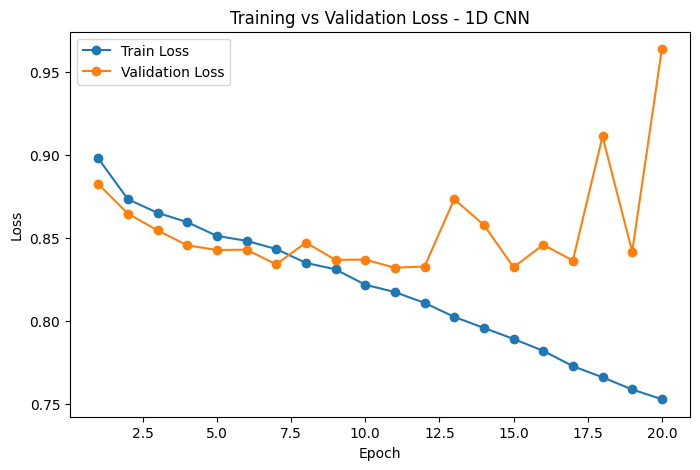

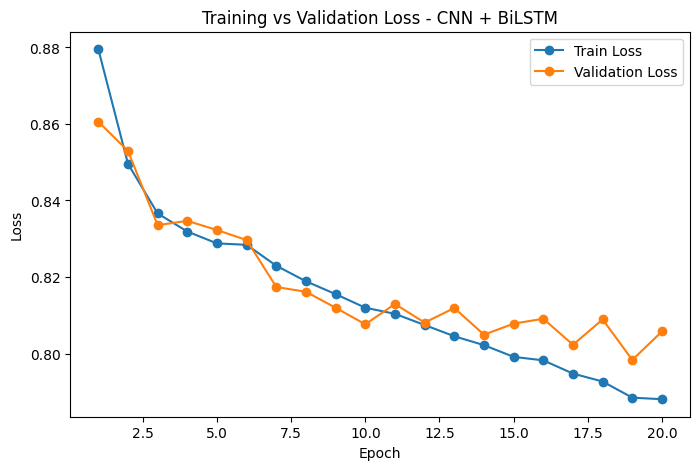

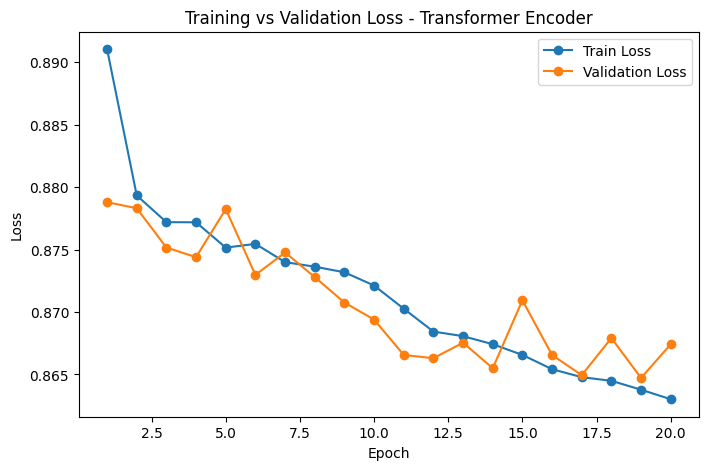

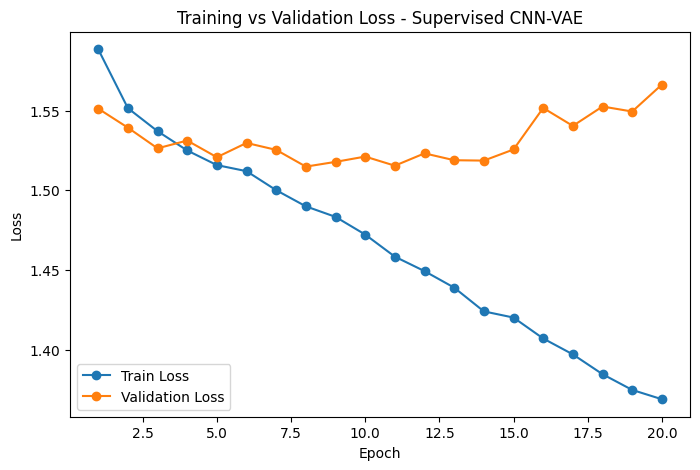

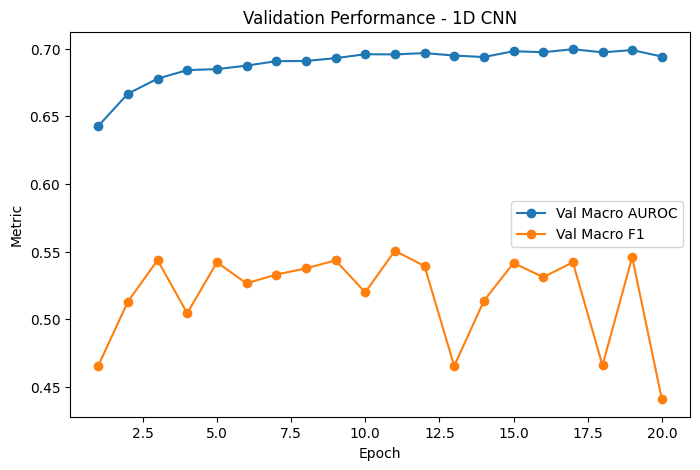

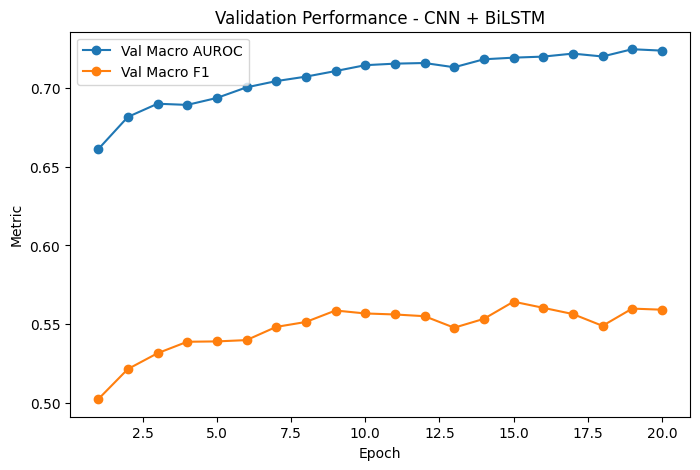

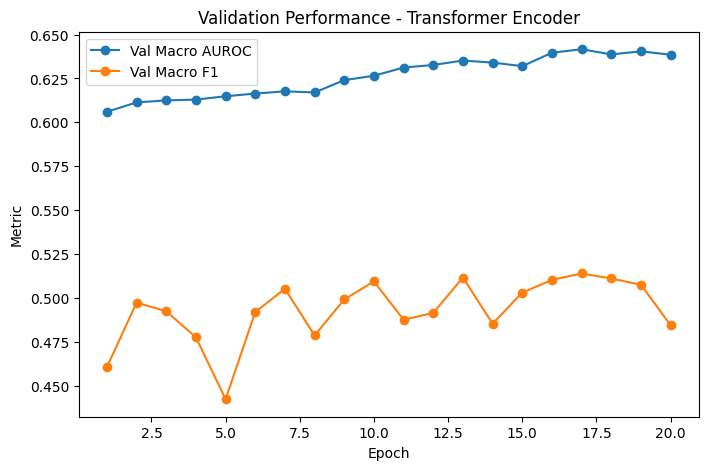

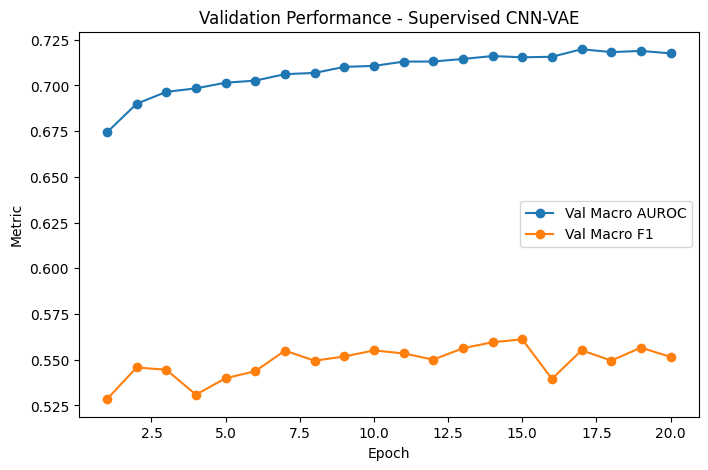

In [ ]:

# 5/6. Check overfitting and underfitting
# Compare train loss vs validation loss and validation AUROC.


histories = {}

if RUN_CNN and cnn_history is not None:
    histories["1D CNN"] = cnn_history

if RUN_CNN_BILSTM and bilstm_history is not None:
    histories["CNN + BiLSTM"] = bilstm_history

if RUN_TRANSFORMER and transformer_history is not None:
    histories["Transformer Encoder"] = transformer_history

if RUN_VAE and vae_history is not None:
    histories["Supervised CNN-VAE"] = vae_history

for name, hist in histories.items():
    plt.figure(figsize=(8, 5))
    plt.plot(hist["epoch"], hist["train_loss"], marker="o", label="Train Loss")
    plt.plot(hist["epoch"], hist["val_loss"], marker="o", label="Validation Loss")
    plt.title(f"Training vs Validation Loss - {name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

for name, hist in histories.items():
    plt.figure(figsize=(8, 5))
    plt.plot(hist["epoch"], hist["val_macro_auroc"], marker="o", label="Val Macro AUROC")
    plt.plot(hist["epoch"], hist["val_macro_f1"], marker="o", label="Val Macro F1")
    plt.title(f"Validation Performance - {name}")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    plt.legend()
    plt.show()

In [ ]:

# 6. Proposed Solution / Model Selection
# Evaluate all trained models on validation and test sets.


trained_models = {}

if RUN_CNN:
    trained_models["1D CNN"] = (cnn_model, False)

if RUN_CNN_BILSTM:
    trained_models["CNN + BiLSTM"] = (bilstm_model, False)

if RUN_TRANSFORMER:
    trained_models["Transformer Encoder"] = (transformer_model, False)

if RUN_VAE:
    trained_models["Supervised CNN-VAE"] = (vae_model, True)

val_results = []
test_results = []

detailed_outputs = {}

for name, (model, is_vae) in trained_models.items():
    print(f"\nEvaluating {name} on validation set...")
    val_metrics, val_y_true, val_logits, val_probs, val_pred, val_label_auroc, val_label_auprc = evaluate_model(
        model,
        val_loader,
        criterion_bce,
        is_vae=is_vae
    )

    print_metrics(val_metrics, prefix="Val ")

    val_row = {"model": name}
    val_row.update(val_metrics)
    val_results.append(val_row)

    print(f"\nEvaluating {name} on test set...")
    test_metrics, test_y_true, test_logits, test_probs, test_pred, test_label_auroc, test_label_auprc = evaluate_model(
        model,
        test_loader,
        criterion_bce,
        is_vae=is_vae
    )

    print_metrics(test_metrics, prefix="Test ")

    test_row = {"model": name}
    test_row.update(test_metrics)
    test_results.append(test_row)

    detailed_outputs[name] = {
        "val": {
            "y_true": val_y_true,
            "logits": val_logits,
            "probs": val_probs,
            "pred": val_pred,
            "per_label_auroc": val_label_auroc,
            "per_label_auprc": val_label_auprc
        },
        "test": {
            "y_true": test_y_true,
            "logits": test_logits,
            "probs": test_probs,
            "pred": test_pred,
            "per_label_auroc": test_label_auroc,
            "per_label_auprc": test_label_auprc
        }
    }

val_results_df = pd.DataFrame(val_results).sort_values(by="macro_auroc", ascending=False)
test_results_df = pd.DataFrame(test_results).sort_values(by="macro_auroc", ascending=False)

print("\nValidation Results:")
display(val_results_df)

print("\nTest Results:")
display(test_results_df)


Evaluating 1D CNN on validation set...
Val macro_auroc: 0.6996
Val macro_auprc: 0.5148
Val micro_auroc: 0.7005
Val macro_f1: 0.5421
Val micro_f1: 0.5543
Val hamming_loss: 0.3523
Val per_label_accuracy: 0.6477
Val exact_match_accuracy: 0.0486
Val loss: 0.8363

Evaluating 1D CNN on test set...
Test macro_auroc: 0.6568
Test macro_auprc: 0.1113
Test micro_auroc: 0.6575
Test macro_f1: 0.1855
Test micro_f1: 0.1886
Test hamming_loss: 0.4226
Test per_label_accuracy: 0.5774
Test exact_match_accuracy: 0.0447
Test loss: 0.7043

Evaluating CNN + BiLSTM on validation set...
Val macro_auroc: 0.7248
Val macro_auprc: 0.5482
Val micro_auroc: 0.7239
Val macro_f1: 0.5599
Val micro_f1: 0.5711
Val hamming_loss: 0.3431
Val per_label_accuracy: 0.6569
Val exact_match_accuracy: 0.0526
Val loss: 0.7983

Evaluating CNN + BiLSTM on test set...
Test macro_auroc: 0.6625
Test macro_auprc: 0.1176
Test micro_auroc: 0.6596
Test macro_f1: 0.1847
Test micro_f1: 0.1861
Test hamming_loss: 0.4336
Test per_label_accuracy: 0

,model,macro_auroc,macro_auprc,micro_auroc,macro_f1,micro_f1,hamming_loss,per_label_accuracy,exact_match_accuracy,loss,reconstruction_accuracy
1,CNN + BiLSTM,0.724780,0.548172,0.723921,0.559855,0.571100,0.343094,0.656906,0.052581,0.798326,NaN
3,Supervised CNN-VAE,0.719775,0.541390,0.725672,0.555163,0.569463,0.334347,0.665653,0.056457,1.540498,0.334549
0,1D CNN,0.699646,0.514815,0.700499,0.542064,0.554350,0.352266,0.647734,0.048583,0.836320,NaN
2,Transformer Encoder,0.641635,0.459125,0.630008,0.514002,0.527145,0.447092,0.552908,0.026654,0.864944,NaN



Test Results:


,model,macro_auroc,macro_auprc,micro_auroc,macro_f1,micro_f1,hamming_loss,per_label_accuracy,exact_match_accuracy,loss,reconstruction_accuracy
3,Supervised CNN-VAE,0.672127,0.116303,0.679391,0.194118,0.198714,0.406414,0.593586,0.062344,1.407295,0.335406
1,CNN + BiLSTM,0.662473,0.117624,0.659625,0.184675,0.186129,0.433569,0.566431,0.051678,0.713796,NaN
0,1D CNN,0.656813,0.111267,0.657484,0.185493,0.188641,0.422578,0.577422,0.044693,0.704277,NaN
2,Transformer Encoder,0.601647,0.098989,0.589112,0.155347,0.157786,0.567247,0.432753,0.044174,0.775004,NaN


,model,loss,macro_auroc,micro_auroc,macro_auprc,macro_f1,micro_f1,hamming_loss,per_label_accuracy,exact_match_accuracy,reconstruction_accuracy
3,Supervised CNN-VAE,1.407295,0.672127,0.679391,0.116303,0.194118,0.198714,0.406414,0.593586,0.062344,0.335406
1,CNN + BiLSTM,0.713796,0.662473,0.659625,0.117624,0.184675,0.186129,0.433569,0.566431,0.051678,NaN
0,1D CNN,0.704277,0.656813,0.657484,0.111267,0.185493,0.188641,0.422578,0.577422,0.044693,NaN
2,Transformer Encoder,0.775004,0.601647,0.589112,0.098989,0.155347,0.157786,0.567247,0.432753,0.044174,NaN


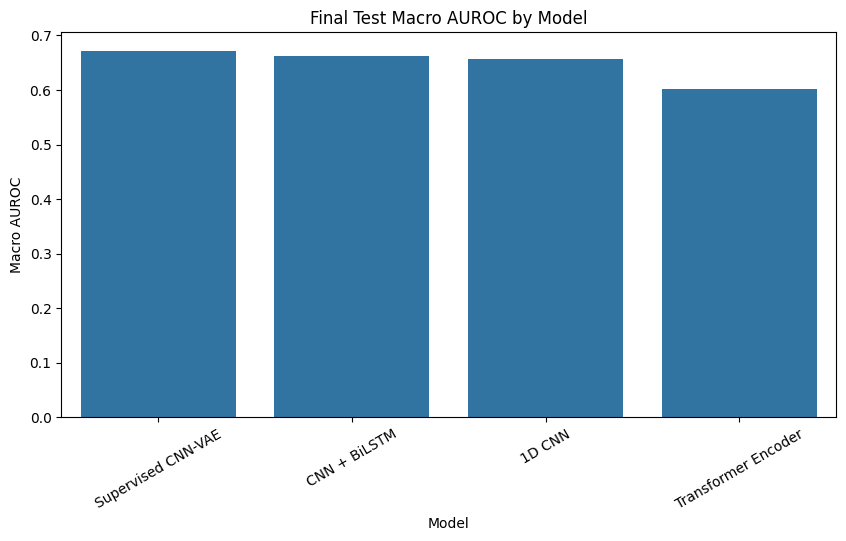

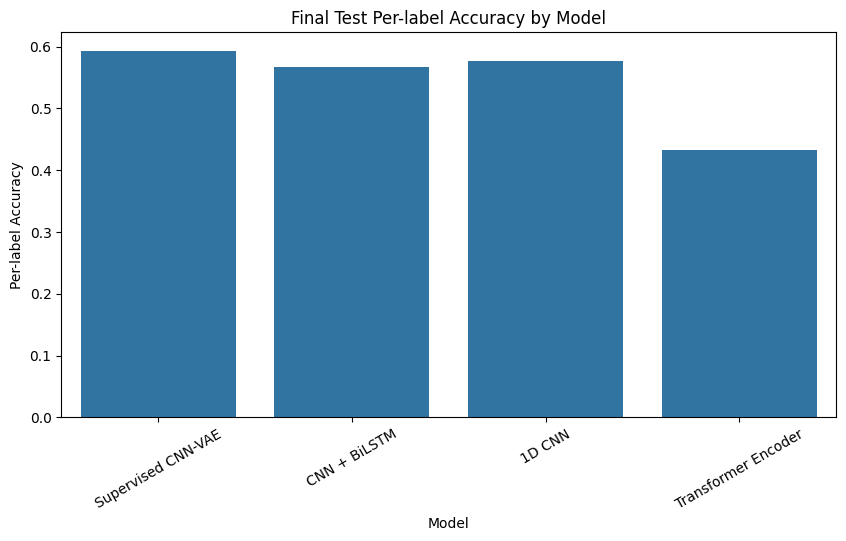

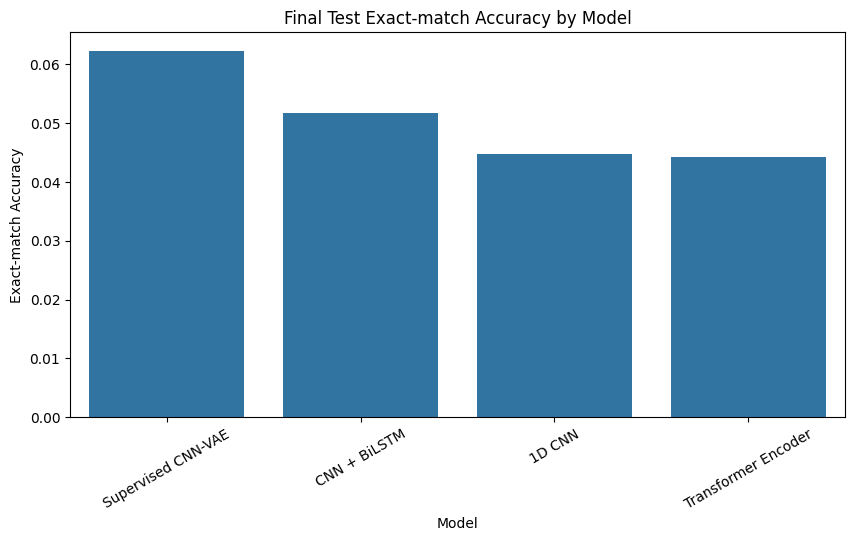

In [ ]:

# 7. Results: Accuracy and other metrics
# Final model comparison


selected_columns = [
    "model",
    "loss",
    "macro_auroc",
    "micro_auroc",
    "macro_auprc",
    "macro_f1",
    "micro_f1",
    "hamming_loss",
    "per_label_accuracy",
    "exact_match_accuracy"
]

# Include reconstruction accuracy if VAE has it
if "reconstruction_accuracy" in test_results_df.columns:
    selected_columns.append("reconstruction_accuracy")

final_comparison = test_results_df[selected_columns].copy()

display(final_comparison)

plt.figure(figsize=(10, 5))
sns.barplot(data=final_comparison, x="model", y="macro_auroc")
plt.title("Final Test Macro AUROC by Model")
plt.xlabel("Model")
plt.ylabel("Macro AUROC")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=final_comparison, x="model", y="per_label_accuracy")
plt.title("Final Test Per-label Accuracy by Model")
plt.xlabel("Model")
plt.ylabel("Per-label Accuracy")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=final_comparison, x="model", y="exact_match_accuracy")
plt.title("Final Test Exact-match Accuracy by Model")
plt.xlabel("Model")
plt.ylabel("Exact-match Accuracy")
plt.xticks(rotation=30)
plt.show()

In [ ]:

# 6. Model Selection
# Select best model using validation Macro AUROC.


best_model_name = val_results_df.iloc[0]["model"]
best_model, best_is_vae = trained_models[best_model_name]

print("Best model selected by validation Macro AUROC:")
print(best_model_name)

print("\nValidation performance of selected model:")
display(val_results_df[val_results_df["model"] == best_model_name])

print("\nTest performance of selected model:")
display(test_results_df[test_results_df["model"] == best_model_name])

Best model selected by validation Macro AUROC:
CNN + BiLSTM

Validation performance of selected model:


,model,macro_auroc,macro_auprc,micro_auroc,macro_f1,micro_f1,hamming_loss,per_label_accuracy,exact_match_accuracy,loss,reconstruction_accuracy
1,CNN + BiLSTM,0.72478,0.548172,0.723921,0.559855,0.5711,0.343094,0.656906,0.052581,0.798326,NaN



Test performance of selected model:


,model,macro_auroc,macro_auprc,micro_auroc,macro_f1,micro_f1,hamming_loss,per_label_accuracy,exact_match_accuracy,loss,reconstruction_accuracy
1,CNN + BiLSTM,0.662473,0.117624,0.659625,0.184675,0.186129,0.433569,0.566431,0.051678,0.713796,NaN


,label,test_auroc,test_auprc
0,H3,0.756575,0.097363
1,H4,0.708654,0.058245
8,H3K79me3,0.692876,0.128664
5,H3K9ac,0.675534,0.126794
7,H3K36me3,0.661739,0.143059
2,H3K4me1,0.648537,0.124414
6,H3K14ac,0.641653,0.132320
9,H4ac,0.640470,0.125462
4,H3K4me3,0.606344,0.129819
3,H3K4me2,0.592353,0.110102


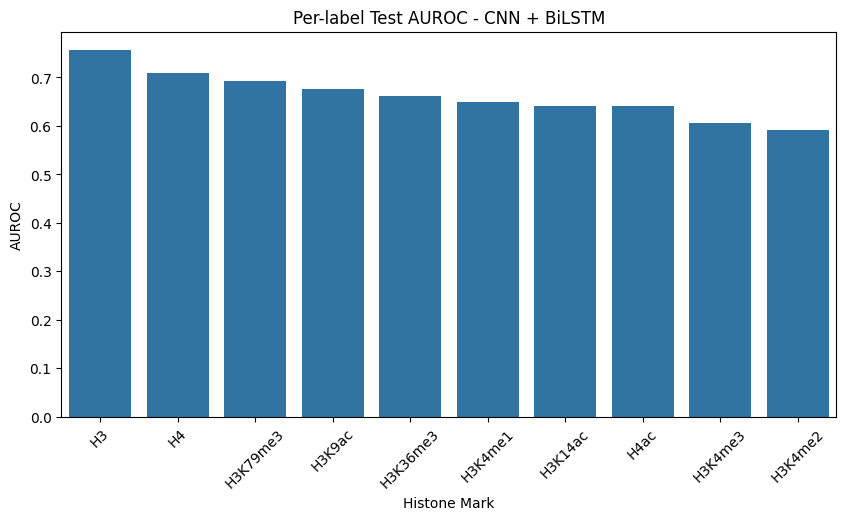

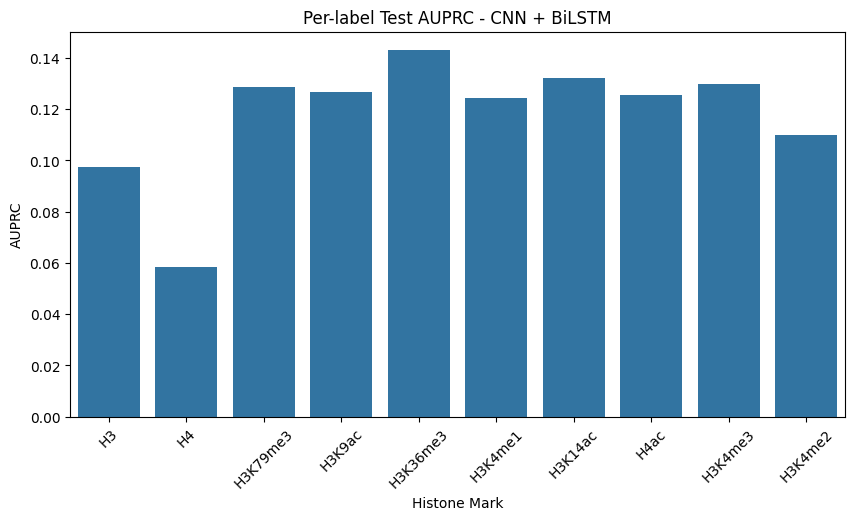

In [ ]:

# Per-label AUROC and AUPRC for selected model


best_test_outputs = detailed_outputs[best_model_name]["test"]

per_label_df = pd.DataFrame({
    "label": HISTONE_TASKS,
    "test_auroc": best_test_outputs["per_label_auroc"],
    "test_auprc": best_test_outputs["per_label_auprc"]
}).sort_values(by="test_auroc", ascending=False)

display(per_label_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=per_label_df, x="label", y="test_auroc")
plt.title(f"Per-label Test AUROC - {best_model_name}")
plt.xlabel("Histone Mark")
plt.ylabel("AUROC")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=per_label_df, x="label", y="test_auprc")
plt.title(f"Per-label Test AUPRC - {best_model_name}")
plt.xlabel("Histone Mark")
plt.ylabel("AUPRC")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# ============================================================
# Detailed classification report for best model
# ============================================================

y_true = best_test_outputs["y_true"]
y_pred = best_test_outputs["pred"]

print(f"Classification report for best model: {best_model_name}")
print(classification_report(
    y_true,
    y_pred,
    target_names=HISTONE_TASKS,
    zero_division=0
))

Classification report for best model: CNN + BiLSTM
              precision    recall  f1-score   support

          H3       0.08      0.72      0.14       767
          H4       0.05      0.85      0.09       648
     H3K4me1       0.11      0.77      0.19      1727
     H3K4me2       0.11      0.62      0.18      1815
     H3K4me3       0.12      0.53      0.20      1960
      H3K9ac       0.12      0.65      0.20      1542
     H3K14ac       0.13      0.61      0.21      1877
    H3K36me3       0.13      0.78      0.22      1889
    H3K79me3       0.12      0.75      0.20      1534
        H4ac       0.13      0.62      0.21      1841

   micro avg       0.11      0.67      0.19     15600
   macro avg       0.11      0.69      0.18     15600
weighted avg       0.11      0.67      0.19     15600
 samples avg       0.10      0.41      0.15     15600



,label,TN,FP,FN,TP
0,H3,13682,6740,218,549
1,H4,10088,10453,97,551
2,H3K4me1,8752,10710,390,1337
3,H3K4me2,10020,9354,694,1121
4,H3K4me3,11728,7501,918,1042
5,H3K9ac,12107,7540,540,1002
6,H3K14ac,11651,7661,732,1145
7,H3K36me3,9055,10245,417,1472
8,H3K79me3,11005,8650,385,1149
9,H4ac,11428,7920,704,1137


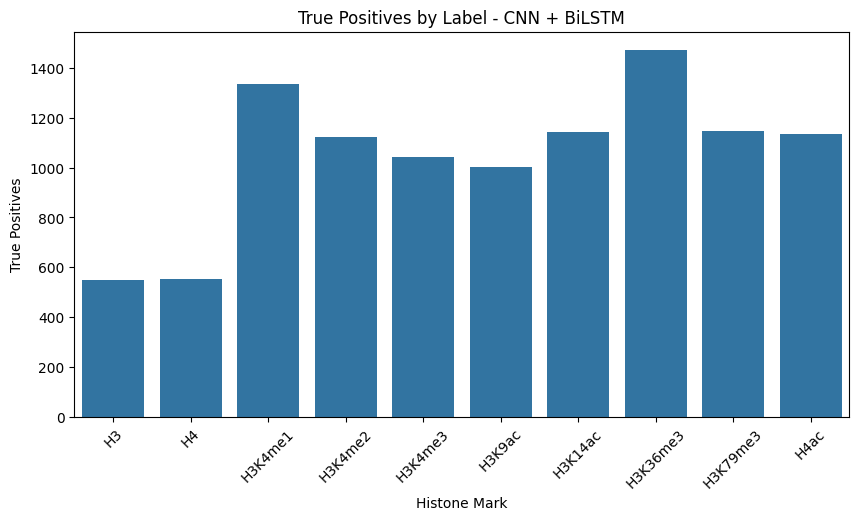

In [ ]:

# Confusion matrix style counts for each label


from sklearn.metrics import confusion_matrix

confusion_rows = []

for j, label in enumerate(HISTONE_TASKS):
    tn, fp, fn, tp = confusion_matrix(y_true[:, j], y_pred[:, j], labels=[0, 1]).ravel()
    confusion_rows.append({
        "label": label,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

confusion_df = pd.DataFrame(confusion_rows)
display(confusion_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=confusion_df, x="label", y="TP")
plt.title(f"True Positives by Label - {best_model_name}")
plt.xlabel("Histone Mark")
plt.ylabel("True Positives")
plt.xticks(rotation=45)
plt.show()

In [ ]:

# Save results


os.makedirs("histone_project_outputs", exist_ok=True)

val_results_df.to_csv("histone_project_outputs/validation_results.csv", index=False)
test_results_df.to_csv("histone_project_outputs/test_results.csv", index=False)
final_comparison.to_csv("histone_project_outputs/final_model_comparison.csv", index=False)
per_label_df.to_csv("histone_project_outputs/best_model_per_label_metrics.csv", index=False)
confusion_df.to_csv("histone_project_outputs/best_model_confusion_counts.csv", index=False)

torch.save(
    best_model.state_dict(),
    f"histone_project_outputs/best_model_{best_model_name.replace(' ', '_').replace('+', 'plus')}.pt"
)

print("Saved outputs to histone_project_outputs/")

Saved outputs to histone_project_outputs/


In [ ]:
# ============================================================
# Save results
# ============================================================

os.makedirs("histone_project_outputs", exist_ok=True)

val_results_df.to_csv("histone_project_outputs/validation_results.csv", index=False)
test_results_df.to_csv("histone_project_outputs/test_results.csv", index=False)
final_comparison.to_csv("histone_project_outputs/final_model_comparison.csv", index=False)
per_label_df.to_csv("histone_project_outputs/best_model_per_label_metrics.csv", index=False)
confusion_df.to_csv("histone_project_outputs/best_model_confusion_counts.csv", index=False)

torch.save(
    best_model.state_dict(),
    f"histone_project_outputs/best_model_{best_model_name.replace(' ', '_').replace('+', 'plus')}.pt"
)

print("Saved outputs to histone_project_outputs/")

Saved outputs to histone_project_outputs/


In [ ]:

# 7. Results and Learnings from Methodology
# Auto-generate clean writeup text based on actual results.


best_val_row = val_results_df.iloc[0]
best_test_row = test_results_df[test_results_df["model"] == best_model_name].iloc[0]

results_summary = f"""
Results and Learnings:

The best model based on validation macro AUROC was the {best_model_name}.
This model achieved a validation macro AUROC of {best_val_row['macro_auroc']:.4f}
and a test macro AUROC of {best_test_row['macro_auroc']:.4f}.

On the test set, the selected model achieved:
- Per-label accuracy: {best_test_row['per_label_accuracy']:.4f}
- Exact-match accuracy: {best_test_row['exact_match_accuracy']:.4f}
- Macro F1-score: {best_test_row['macro_f1']:.4f}
- Hamming loss: {best_test_row['hamming_loss']:.4f}

The use of macro AUROC as the primary metric was important because this is a
multi-label classification problem with possible label imbalance. Accuracy was
still reported for interpretability, but exact-match accuracy is stricter because
it requires all ten histone labels for a sequence to be predicted correctly.

Comparing the four architectures allowed the project to evaluate increasingly
complex deep learning approaches: a CNN baseline for local motifs, a CNN+BiLSTM
for sequence order, a Transformer Encoder for attention-based context, and a
supervised CNN-VAE for latent representation learning.
"""

print(results_summary)


Results and Learnings:

The best model based on validation macro AUROC was the CNN + BiLSTM.
This model achieved a validation macro AUROC of 0.7248
and a test macro AUROC of 0.6625.

On the test set, the selected model achieved:
- Per-label accuracy: 0.5664
- Exact-match accuracy: 0.0517
- Macro F1-score: 0.1847
- Hamming loss: 0.4336

The use of macro AUROC as the primary metric was important because this is a
multi-label classification problem with possible label imbalance. Accuracy was
still reported for interpretability, but exact-match accuracy is stricter because
it requires all ten histone labels for a sequence to be predicted correctly.

Comparing the four architectures allowed the project to evaluate increasingly
complex deep learning approaches: a CNN baseline for local motifs, a CNN+BiLSTM
for sequence order, a Transformer Encoder for attention-based context, and a
supervised CNN-VAE for latent representation learning.



Test batch keys: ['input_ids', 'attention_mask', 'labels']
No mask key in batch — pulling masks from val_df / test_df instead.

Re-evaluating: 1D CNN

Re-evaluating: CNN + BiLSTM

Re-evaluating: Transformer Encoder

Re-evaluating: Supervised CNN-VAE

=== Re-evaluated metrics with proper masking ===
              Model  val mean_AUROC  test mean_AUROC  val macro_F1 (thr=.5)  test macro_F1 (thr=.5)  test macro_F1 (tuned)  test mean_AUPRC
 Supervised CNN-VAE          0.7975           0.8482                 0.7108                  0.7535                 0.7999           0.8616
             1D CNN          0.7749           0.8210                 0.7028                  0.7357                 0.7833           0.8339
       CNN + BiLSTM          0.8049           0.8121                 0.7294                  0.7371                 0.7876           0.8272
Transformer Encoder          0.6886           0.6888                 0.6890                  0.6867                 0.7297           0.7041


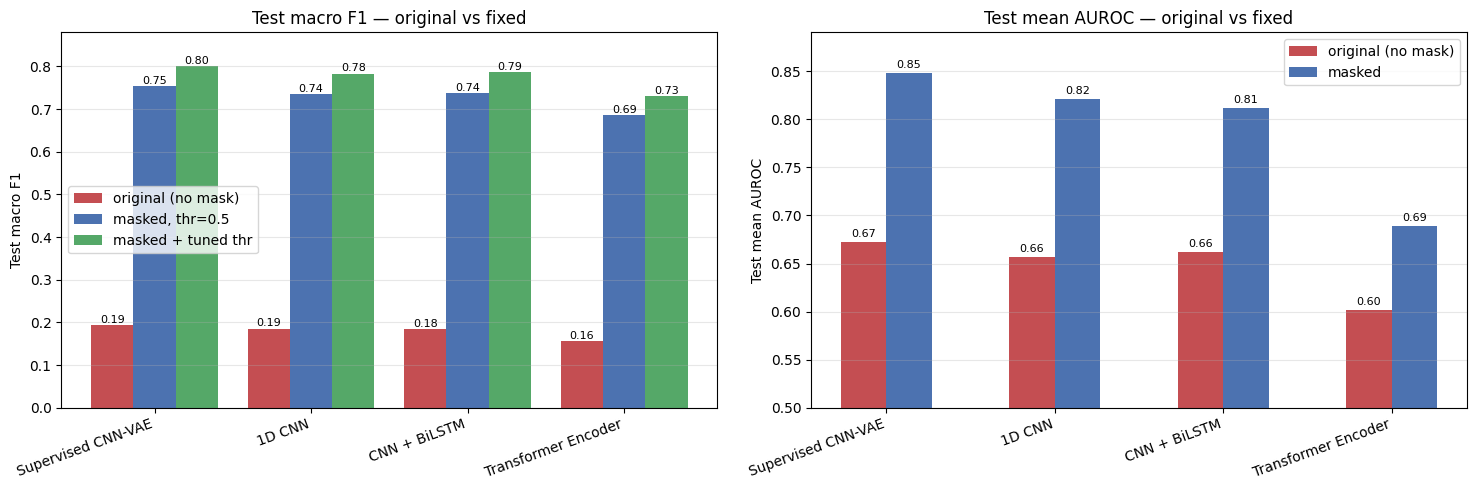

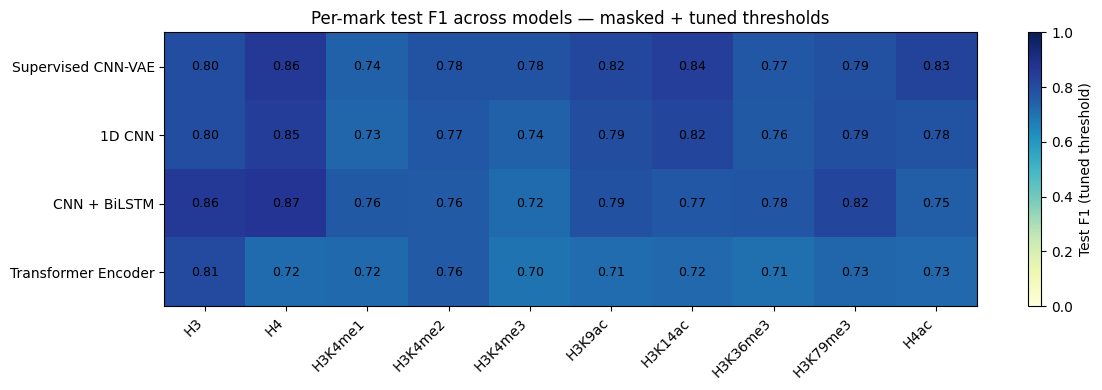


Best model after fix: Supervised CNN-VAE
   label    n  thr       f1    auroc    auprc
      H3 1497 0.11 0.800000 0.882404 0.876758
      H4 1461 0.20 0.856061 0.922213 0.881577
 H3K4me1 3168 0.29 0.741754 0.771547 0.798811
 H3K4me2 3069 0.29 0.778173 0.776892 0.824676
 H3K4me3 3680 0.27 0.780702 0.824367 0.830073
  H3K9ac 2779 0.26 0.815224 0.861341 0.882085
 H3K14ac 3305 0.22 0.840969 0.891853 0.910532
H3K36me3 3488 0.31 0.768593 0.823765 0.859431
H3K79me3 2884 0.32 0.788758 0.840225 0.856553
    H4ac 3410 0.25 0.828437 0.887740 0.895950


In [ ]:

# PATCH: Recompute test metrics with proper label masking
#
# Paste this as a single new cell at the end of your notebook,
# AFTER cells 19-25 (model training) and AFTER cell 27 (which
# builds `trained_models`, `test_results_df`, etc.).
#
# What it does:
#   1. Re-runs each trained model on the val and test loaders.
#   2. Computes per-label metrics using only OBSERVED entries
#      (the *_mask columns), instead of treating unobserved labels
#      as negatives.
#   3. Tunes per-label thresholds on the val set to maximize F1.
#   4. Plots original vs fixed test F1 / AUROC, plus a per-mark
#      F1 heatmap across models.

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score


# ---------- 1. Find the mask in the dataloader (or fall back to dataframes) ----------
_sample = next(iter(test_loader))
print("Test batch keys:", list(_sample.keys()))

MASK_KEY = next((k for k in ['mask', 'labels_mask', 'label_mask'] if k in _sample), None)

if MASK_KEY is None:
    print("No mask key in batch — pulling masks from val_df / test_df instead.")
    _MASK_COLS = [f"{h}_mask" for h in HISTONE_TASKS]
    val_mask_full  = val_df[_MASK_COLS].values.astype(np.float32)
    test_mask_full = test_df[_MASK_COLS].values.astype(np.float32)
else:
    print(f"Using batch[{MASK_KEY!r}] as the mask.")
    val_mask_full = test_mask_full = None


# ---------- 2. Inference helper ----------
@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    probs_l, y_l, m_l = [], [], []
    for batch in loader:
        x = batch["input_ids"].to(DEVICE)
        out = model(x)
        if isinstance(out, dict):
            logits = out.get("logits", out.get("class_logits"))
        elif isinstance(out, (tuple, list)):
            logits = out[0]
        else:
            logits = out
        probs_l.append(torch.sigmoid(logits.float()).cpu().numpy())
        y_l.append(batch["labels"].cpu().numpy())
        if MASK_KEY is not None:
            m_l.append(batch[MASK_KEY].cpu().numpy())
    probs = np.concatenate(probs_l)
    y     = np.concatenate(y_l)
    mask  = np.concatenate(m_l) if m_l else None
    return probs, y, mask


# ---------- 3. Masked metrics ----------
def masked_metrics(probs, y, mask, thresholds=0.5):
    """Per-label + macro/micro metrics using only entries where mask == 1.
    `thresholds` may be a scalar or an array of length n_labels."""
    n_labels = y.shape[1]
    if np.isscalar(thresholds):
        thresholds = np.full(n_labels, thresholds, dtype=np.float32)

    rows, micro_y, micro_p, micro_pred = [], [], [], []
    for li, label in enumerate(HISTONE_TASKS):
        m = mask[:, li].astype(bool)
        if m.sum() == 0:
            rows.append({'label': label, 'n': 0, 'thr': thresholds[li],
                         'f1': np.nan, 'auroc': np.nan, 'auprc': np.nan})
            continue
        yt    = y[m, li].astype(int)
        yp    = probs[m, li]
        ypred = (yp >= thresholds[li]).astype(int)
        try:
            auroc = roc_auc_score(yt, yp) if len(np.unique(yt)) > 1 else np.nan
            auprc = average_precision_score(yt, yp) if len(np.unique(yt)) > 1 else np.nan
        except ValueError:
            auroc = auprc = np.nan
        rows.append({
            'label': label, 'n': int(m.sum()), 'thr': float(thresholds[li]),
            'f1': f1_score(yt, ypred, zero_division=0),
            'auroc': auroc, 'auprc': auprc,
        })
        micro_y.append(yt); micro_p.append(yp); micro_pred.append(ypred)

    df = pd.DataFrame(rows)
    summary = {
        'macro_f1':   df['f1'].mean(skipna=True),
        'mean_auroc': df['auroc'].mean(skipna=True),
        'mean_auprc': df['auprc'].mean(skipna=True),
    }
    if micro_y:
        my = np.concatenate(micro_y)
        mp = np.concatenate(micro_p)
        mpred = np.concatenate(micro_pred)
        summary['micro_f1']    = f1_score(my, mpred, zero_division=0)
        summary['micro_auroc'] = roc_auc_score(my, mp) if len(np.unique(my)) > 1 else np.nan
    return df, summary


def tune_thresholds(probs, y, mask, grid=None):
    """Per-label thresholds that maximize masked F1 on validation."""
    if grid is None:
        grid = np.linspace(0.05, 0.95, 91)
    thr = np.full(y.shape[1], 0.5, dtype=np.float32)
    for li in range(y.shape[1]):
        m = mask[:, li].astype(bool)
        if m.sum() == 0:
            continue
        yt = y[m, li].astype(int)
        yp = probs[m, li]
        best_f1, best_t = -1.0, 0.5
        for t in grid:
            f = f1_score(yt, (yp >= t).astype(int), zero_division=0)
            if f > best_f1:
                best_f1, best_t = f, t
        thr[li] = best_t
    return thr


# ---------- 4. Re-evaluate every trained model ----------
fixed_rows = []
fixed_perlabel = {}

for name, model_entry in trained_models.items():
    # `trained_models` is name -> (model, is_vae)
    model = model_entry[0] if isinstance(model_entry, tuple) else model_entry
    print(f"\nRe-evaluating: {name}")

    val_probs,  val_y,  val_m  = predict_loader(model, val_loader)
    test_probs, test_y, test_m = predict_loader(model, test_loader)

    if val_m  is None: val_m  = val_mask_full
    if test_m is None: test_m = test_mask_full

    if val_m.shape[0] != val_probs.shape[0]:
        raise RuntimeError(
            f"val mask size ({val_m.shape[0]}) != val probs ({val_probs.shape[0]}). "
            "Make sure val_loader was built with shuffle=False, and that val_df "
            "is in the same row order."
        )
    if test_m.shape[0] != test_probs.shape[0]:
        raise RuntimeError(
            f"test mask size ({test_m.shape[0]}) != test probs ({test_probs.shape[0]}). "
            "Make sure test_loader was built with shuffle=False."
        )

    # (a) default 0.5 threshold, masked
    val_pl_5,  val_sum_5  = masked_metrics(val_probs,  val_y,  val_m,  thresholds=0.5)
    test_pl_5, test_sum_5 = masked_metrics(test_probs, test_y, test_m, thresholds=0.5)

    # (b) tune per-label thresholds on val, re-evaluate test
    thr = tune_thresholds(val_probs, val_y, val_m)
    test_pl_t, test_sum_t = masked_metrics(test_probs, test_y, test_m, thresholds=thr)

    fixed_rows.append({
        'Model': name,
        'val mean_AUROC':         round(val_sum_5['mean_auroc'],  4),
        'test mean_AUROC':        round(test_sum_5['mean_auroc'], 4),
        'val macro_F1 (thr=.5)':  round(val_sum_5['macro_f1'],    4),
        'test macro_F1 (thr=.5)': round(test_sum_5['macro_f1'],   4),
        'test macro_F1 (tuned)':  round(test_sum_t['macro_f1'],   4),
        'test mean_AUPRC':        round(test_sum_5['mean_auprc'], 4),
    })
    fixed_perlabel[name] = {
        'val_default':  val_pl_5,
        'test_default': test_pl_5,
        'test_tuned':   test_pl_t,
        'thresholds':   thr,
    }

summary_fixed = (pd.DataFrame(fixed_rows)
                 .sort_values('test mean_AUROC', ascending=False)
                 .reset_index(drop=True))
print("\n=== Re-evaluated metrics with proper masking ===")
print(summary_fixed.to_string(index=False))


# ---------- 5. Visualize: original vs fixed ----------
names = summary_fixed['Model'].tolist()

orig_f1   = test_results_df.set_index('model').loc[names, 'macro_f1'].values
fixed_f1  = summary_fixed['test macro_F1 (thr=.5)'].values
tuned_f1  = summary_fixed['test macro_F1 (tuned)'].values

orig_auc  = test_results_df.set_index('model').loc[names, 'macro_auroc'].values
fixed_auc = summary_fixed['test mean_AUROC'].values

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(names))
w = 0.27

axes[0].bar(x - w, orig_f1,  w, label='original (no mask)',  color='#C44E52')
axes[0].bar(x,     fixed_f1, w, label='masked, thr=0.5',     color='#4C72B0')
axes[0].bar(x + w, tuned_f1, w, label='masked + tuned thr',  color='#55A868')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=20, ha='right')
axes[0].set_ylabel('Test macro F1')
axes[0].set_title('Test macro F1 — original vs fixed')
axes[0].legend(loc='best')
axes[0].set_ylim(0, max(0.7, tuned_f1.max() * 1.1))
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(orig_f1):  axes[0].text(i - w, v + 0.005, f'{v:.2f}', ha='center', fontsize=8)
for i, v in enumerate(fixed_f1): axes[0].text(i,     v + 0.005, f'{v:.2f}', ha='center', fontsize=8)
for i, v in enumerate(tuned_f1): axes[0].text(i + w, v + 0.005, f'{v:.2f}', ha='center', fontsize=8)

axes[1].bar(x - w/2, orig_auc,  w, label='original (no mask)', color='#C44E52')
axes[1].bar(x + w/2, fixed_auc, w, label='masked',             color='#4C72B0')
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=20, ha='right')
axes[1].set_ylabel('Test mean AUROC')
axes[1].set_title('Test mean AUROC — original vs fixed')
axes[1].legend(loc='best')
axes[1].set_ylim(0.5, max(0.85, fixed_auc.max() * 1.05))
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(orig_auc):  axes[1].text(i - w/2, v + 0.005, f'{v:.2f}', ha='center', fontsize=8)
for i, v in enumerate(fixed_auc): axes[1].text(i + w/2, v + 0.005, f'{v:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()


# ---------- 6. Heatmap: per-mark F1 (tuned thresholds) across models ----------
F = np.full((len(names), len(HISTONE_TASKS)), np.nan)
for i, n in enumerate(names):
    pl = fixed_perlabel[n]['test_tuned'].set_index('label').reindex(HISTONE_TASKS)
    F[i] = pl['f1'].values

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(F, aspect='auto', cmap='YlGnBu', vmin=0, vmax=1)
ax.set_xticks(range(len(HISTONE_TASKS)))
ax.set_xticklabels(HISTONE_TASKS, rotation=45, ha='right')
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
for i in range(F.shape[0]):
    for j in range(F.shape[1]):
        if not np.isnan(F[i, j]):
            ax.text(j, i, f'{F[i, j]:.2f}', ha='center', va='center',
                    color='white' if F[i, j] < 0.4 else 'black', fontsize=9)
plt.colorbar(im, ax=ax, label='Test F1 (tuned threshold)')
ax.set_title('Per-mark test F1 across models — masked + tuned thresholds')
plt.tight_layout()
plt.show()


# ---------- 7. Per-mark detail for the best model ----------
best_name = summary_fixed.iloc[0]['Model']
print(f"\nBest model after fix: {best_name}")
print(fixed_perlabel[best_name]['test_tuned'][['label', 'n', 'thr', 'f1', 'auroc', 'auprc']].to_string(index=False))

In [ ]:

from google.colab import output
output.disable_custom_widget_manager()

In [ ]:
import json

input_file = "/content/drive/MyDrive/Colab Notebooks/deeplearning_for_histone_mods.ipynb"
output_file = "/content/drive/MyDrive/Colab Notebooks/deeplearning_for_histone_mods.ipynb"

with open(input_file, "r", encoding="utf-8") as f:
    nb = json.load(f)

# Remove broken widget metadata
if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

# Also clean cell-level widget/output metadata if present
for cell in nb.get("cells", []):
    cell.pop("metadata", None)
    for output in cell.get("outputs", []):
        output.pop("metadata", None)

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=1)

print("Clean notebook saved as:", output_file)

FileNotFoundError: [Errno 2] No such file or directory: "/content/drive/MyDrive/'Colab Notebooks'/deeplearning_for_histone_mods.ipynb"

In [ ]:
!git config --global user.name "jenithapatel"
!git config --global user.email "jenitha.patel@gmail.com"